<a href="https://colab.research.google.com/github/cewgs/Data-Analysis-and-Visualisation/blob/main/data_visualitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

In [2]:
# import google drive data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load data
df = pd.read_csv(r"/content/drive/MyDrive/data/Kaggle/housing_data_melbourne/melb_data.csv")
geo_data = gpd.read_file(r"/content/drive/MyDrive/data/Kaggle/housing_data_melbourne/vic-2-clean.geojson")

# Data Overview

# Data Types and Structure

Dataset Column Description
| **Column Name**   | **Description**                                                                                                                                                                                                                                                                                 | **Data Type / Example Values** |
|--------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------|
| **Rooms**          | Number of rooms in the property.                                                                                                                                                                                                                                                                | Numeric (e.g., 2, 3, 4) |
| **Price**          | Sale price of the property in dollars.                                                                                                                                                                                                                                                          | Numeric (e.g., 850000) |
| **Method**         | Method of sale: <br>• **S** – Sold <br>• **SP** – Sold prior <br>• **PI** – Passed in <br>• **PN** – Sold prior not disclosed <br>• **SN** – Sold not disclosed <br>• **NB** – No bid <br>• **VB** – Vendor bid <br>• **W** – Withdrawn prior to auction <br>• **SA** – Sold after auction <br>• **SS** – Sold after auction price not disclosed <br>• **N/A** – Price or bid not available. | Categorical |
| **Type**           | Property type: <br>• **br** – Bedroom(s) <br>• **h** – House, cottage, villa, semi, terrace <br>• **u** – Unit, duplex <br>• **t** – Townhouse <br>• **dev site** – Development site <br>• **o res** – Other residential.                                                                          | Categorical |
| **SellerG**        | Real estate agency or agent responsible for the sale.                                                                                                                                                                                                                                           | Text (e.g., “Jellis”, “Nelson”) |
| **Date**           | Date when the property was sold.                                                                                                                                                                                                                                                                | Date (e.g., 2017-09-23) |
| **Distance**       | Distance of the property from the Central Business District (CBD), measured in kilometers.                                                                                                                                                                                                      | Numeric (e.g., 5.4) |
| **Regionname**     | General region or area where the property is located (e.g., West, North West, North East, etc.).                                                                                                                                                                                                | Categorical |
| **Propertycount**  | Number of total properties within the suburb.                                                                                                                                                                                                                                                   | Numeric |
| **Bedroom2**       | Number of bedrooms (scraped from a secondary data source for validation).                                                                                                                                                                                                                       | Numeric |
| **Bathroom**       | Number of bathrooms.                                                                                                                                                                                                                                                                            | Numeric |
| **Car**            | Number of car parking spaces.                                                                                                                                                                                                                                                                   | Numeric |
| **Landsize**       | Size of the land plot (square meters).                                                                                                                                                                                                                                                          | Numeric |
| **BuildingArea**   | Size of the building structure (square meters).                                                                                                                                                                                                                                                 | Numeric |
| **CouncilArea**    | Name of the local government or council governing the area.                                                                                                                                                                                                                                     | Text (e.g., “Yarra City Council”) |


### Data Cleaning

In [4]:
df.shape

(13580, 21)

In [5]:
df.isna().sum() # the building area is crucial but NAN are too many so we drop everything with NAN

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [6]:
# drop missing values
df.dropna(inplace=True)

# define dtypes
df['Rooms'] = df['Rooms'].astype(int)
df['Price'] = df['Price'].astype(int)
#post code
df["Postcode"] = df["Postcode"].astype(int)
df['Postcode'] = df['Postcode'].astype(str)

df['Bathroom'] = df['Bathroom'].astype(int)
df['Bedroom2'] = df['Bedroom2'].astype(int)

df['Car'] = df['Car'].astype(int)
df['Landsize'] = df['Landsize'].astype(int)
df['BuildingArea'] = df['BuildingArea'].astype(int)
df['Propertycount'] = df['Propertycount'].astype(int)

# dates
df['YearBuilt'] = df['YearBuilt'].astype(int)
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y", errors='coerce')

# cut values smaller than 20 from building size
df = df[df['BuildingArea'] > 20]

df.shape

(6152, 21)

In [7]:
# create the new feature price per bulding size
df['price_size'] = df['Price'] / df['BuildingArea']
# round the new feature
df['price_size'] = df['price_size'].round(0)

In [8]:
# drop bedroom 2 and price
df.drop(columns=['Bedroom2'], inplace=True)

In [9]:
# Outliers
# check for outliers
columns_to_check = [
    "Distance", "Landsize", "BuildingArea", "Propertycount",
    "Rooms", "Bathroom", "Car", "Lattitude", "Longtitude","price_size","Price"
]

# scoress
z = np.abs(stats.zscore(df[columns_to_check], nan_policy='omit'))

# z < 3
df = df[(z < 3).all(axis=1)].copy()

# Filter out rows where Landsize is less than BuildingArea
df = df[df['Landsize'] >= df['BuildingArea']].copy()

print(f"DataFrame shape after outlier removal: {df.shape}")

DataFrame shape after outlier removal: (4300, 21)


In [10]:
df.shape

(4300, 21)

In [11]:
# df describe
print("DataFrame Overview:")
display(df.describe())
display(f'The shape of the dataset is {df.shape}')
display(df.info())

DataFrame Overview:


,Rooms,Price,Date,Distance,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,price_size
count,4300.000000,4.300000e+03,4300,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,3.073488,1.115553e+06,2016-12-23 17:02:44.093022976,10.000023,1.570000,1.592326,494.808372,145.548140,1959.044651,-37.803833,144.992258,6720.352558,8015.310233
min,1.000000,1.310000e+05,2016-02-04 00:00:00,0.000000,1.000000,0.000000,30.000000,26.000000,1196.000000,-38.015960,144.695660,389.000000,845.000000
25%,3.000000,7.150000e+05,2016-08-22 00:00:00,6.800000,1.000000,1.000000,258.000000,104.000000,1930.000000,-37.853777,144.916947,3755.000000,5826.250000
50%,3.000000,9.800000e+05,2016-11-27 00:00:00,9.500000,1.000000,2.000000,472.000000,132.000000,1960.000000,-37.794875,144.998400,6232.000000,7586.000000
75%,4.000000,1.400000e+06,2017-05-27 00:00:00,13.000000,2.000000,2.000000,650.000000,176.000000,1993.000000,-37.752897,145.062400,8920.000000,9668.750000
max,5.000000,3.085000e+06,2017-08-12 00:00:00,26.100000,3.000000,4.000000,3093.000000,411.000000,2018.000000,-37.582420,145.286880,17496.000000,19688.000000
std,0.845438,5.310236e+05,NaN,4.463596,0.638737,0.848674,324.723945,60.599623,38.937157,0.071939,0.095356,3546.980036,3037.522414


'The shape of the dataset is (4300, 21)'

<class 'pandas.core.frame.DataFrame'>
Index: 4300 entries, 1 to 12206
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         4300 non-null   object        
 1   Address        4300 non-null   object        
 2   Rooms          4300 non-null   int64         
 3   Type           4300 non-null   object        
 4   Price          4300 non-null   int64         
 5   Method         4300 non-null   object        
 6   SellerG        4300 non-null   object        
 7   Date           4300 non-null   datetime64[ns]
 8   Distance       4300 non-null   float64       
 9   Postcode       4300 non-null   object        
 10  Bathroom       4300 non-null   int64         
 11  Car            4300 non-null   int64         
 12  Landsize       4300 non-null   int64         
 13  BuildingArea   4300 non-null   int64         
 14  YearBuilt      4300 non-null   int64         
 15  CouncilArea    4300 non-n

None

In [12]:
# rename for h, t, u in type:
df['Type'] = df['Type'].replace({'h': 'house', 't': 'townhouse', 'u': 'duplex'})

# rename methods
df['Method']  = df['Method'].replace({
    'S': 'sold',
    'SP': 'sold prior',
    'PI': 'passed in',
    'PN': 'sold prior not disclosed',
    'SN': 'sold not disclosed'
})

### Numerical Data

In [13]:
# store numeric and categorical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

display(df.describe())


,Rooms,Price,Date,Distance,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,price_size
count,4300.000000,4.300000e+03,4300,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,3.073488,1.115553e+06,2016-12-23 17:02:44.093022976,10.000023,1.570000,1.592326,494.808372,145.548140,1959.044651,-37.803833,144.992258,6720.352558,8015.310233
min,1.000000,1.310000e+05,2016-02-04 00:00:00,0.000000,1.000000,0.000000,30.000000,26.000000,1196.000000,-38.015960,144.695660,389.000000,845.000000
25%,3.000000,7.150000e+05,2016-08-22 00:00:00,6.800000,1.000000,1.000000,258.000000,104.000000,1930.000000,-37.853777,144.916947,3755.000000,5826.250000
50%,3.000000,9.800000e+05,2016-11-27 00:00:00,9.500000,1.000000,2.000000,472.000000,132.000000,1960.000000,-37.794875,144.998400,6232.000000,7586.000000
75%,4.000000,1.400000e+06,2017-05-27 00:00:00,13.000000,2.000000,2.000000,650.000000,176.000000,1993.000000,-37.752897,145.062400,8920.000000,9668.750000
max,5.000000,3.085000e+06,2017-08-12 00:00:00,26.100000,3.000000,4.000000,3093.000000,411.000000,2018.000000,-37.582420,145.286880,17496.000000,19688.000000
std,0.845438,5.310236e+05,NaN,4.463596,0.638737,0.848674,324.723945,60.599623,38.937157,0.071939,0.095356,3546.980036,3037.522414


### Categorical Data & Binary Data

In [14]:
display(df[categorical_columns].head())
print("\n")
display(df.describe(include="object"))

,Suburb,Address,Type,Method,SellerG,Postcode,CouncilArea,Regionname
1,Abbotsford,25 Bloomburg St,house,sold,Biggin,3067,Yarra,Northern Metropolitan
6,Abbotsford,124 Yarra St,house,sold,Nelson,3067,Yarra,Northern Metropolitan
7,Abbotsford,98 Charles St,house,sold,Nelson,3067,Yarra,Northern Metropolitan
9,Abbotsford,10 Valiant St,house,sold,Biggin,3067,Yarra,Northern Metropolitan
11,Abbotsford,40 Nicholson St,house,VB,Nelson,3067,Yarra,Northern Metropolitan


,Suburb,Address,Type,Method,SellerG,Postcode,CouncilArea,Regionname
count,4300,4300,4300,4300,4300,4300,4300,4300
unique,240,4245,3,5,168,150,26,6
top,Bentleigh East,1/1 Clarendon St,house,sold,Nelson,3046,Moreland,Southern Metropolitan
freq,96,3,3359,2866,552,134,531,1395


# Location Metrics

### Metrics for numerical data

In [15]:
# mode, median, mean, qunantils for numeric features
# all numeric features
for col in numeric_columns:

    mode_val = df[col].mode()
    median_val = df[col].median()
    mean_val = df[col].mean()
    var_val = df[col].var()
    std_val = df[col].std()

    # Quartile
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    print(f"Column: {col}")
    print(f"  Mode(s): {mode_val.to_list()}") # more than one i
    print(f"  Median: {median_val:.2f}")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Variance: {var_val:.2f}")
    print(f"  Standard Deviation: {std_val:.2f}")
    print(f"  Q1 (25th percentile): {q1:.2f}")
    print(f"  Q3 (75th percentile): {q3:.2f}")
    print(f"  IQR (Q3 - Q1): {iqr:.2f}")
    print("-" * 50)


Column: Rooms
  Mode(s): [3]
  Median: 3.00
  Mean: 3.07
  Variance: 0.71
  Standard Deviation: 0.85
  Q1 (25th percentile): 3.00
  Q3 (75th percentile): 4.00
  IQR (Q3 - Q1): 1.00
--------------------------------------------------
Column: Price
  Mode(s): [1100000, 1300000]
  Median: 980000.00
  Mean: 1115552.90
  Variance: 281986061216.74
  Standard Deviation: 531023.60
  Q1 (25th percentile): 715000.00
  Q3 (75th percentile): 1400000.00
  IQR (Q3 - Q1): 685000.00
--------------------------------------------------
Column: Distance
  Mode(s): [11.2]
  Median: 9.50
  Mean: 10.00
  Variance: 19.92
  Standard Deviation: 4.46
  Q1 (25th percentile): 6.80
  Q3 (75th percentile): 13.00
  IQR (Q3 - Q1): 6.20
--------------------------------------------------
Column: Bathroom
  Mode(s): [1]
  Median: 1.00
  Mean: 1.57
  Variance: 0.41
  Standard Deviation: 0.64
  Q1 (25th percentile): 1.00
  Q3 (75th percentile): 2.00
  IQR (Q3 - Q1): 1.00
--------------------------------------------------
Co

### Metrics for categorical Data

In [16]:
'''
# categorical columns
for col in categorical_columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
'''

"\n# categorical columns\nfor col in categorical_columns:\n    plt.figure(figsize=(8, 6))\n    sns.countplot(data=df, x=col)\n    plt.title(f'Distribution of {col}')\n    plt.xlabel(col)\n    plt.ylabel('Frequency')\n"

In [17]:
# Frequencies for Type
print("Frequencies for Property Type:")
display(df['Type'].value_counts())

# Frequencies for Method
print("\nFrequencies for Method of Sale:")
display(df['Method'].value_counts())

Frequencies for Property Type:


,count
Type,
house,3359
duplex,540
townhouse,401



Frequencies for Method of Sale:


,count
Method,
sold,2866
sold prior,572
passed in,515
VB,322
SA,25


# Data Analysis

### Correlation Matrix

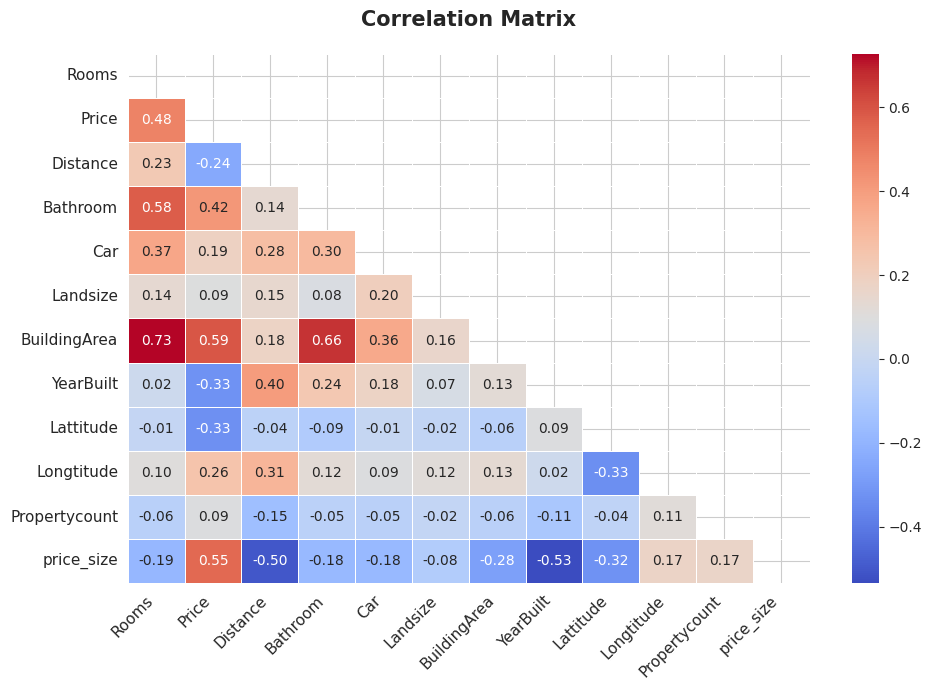

In [18]:
sns.set_style("whitegrid")

#correlation matrix
corr_matrix = df[numeric_columns].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            linecolor='white',

            annot_kws={'fontsize': 10})

plt.title('Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.savefig('correlation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()


#files.download('correlation.png')

### Covariance Matrix

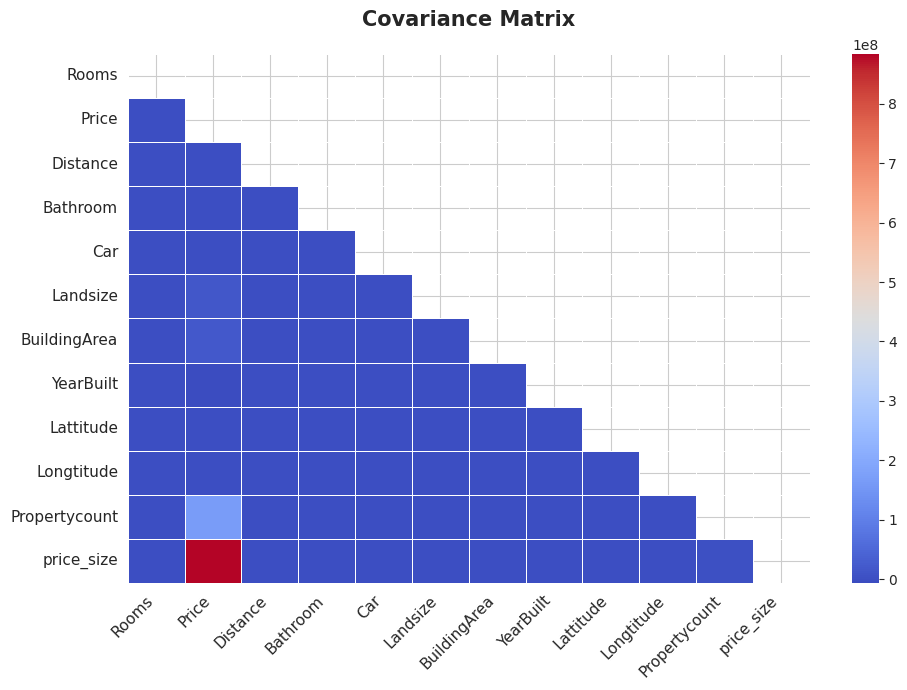

In [19]:
# Covariance matrix
cov_matrix = df[numeric_columns].cov()
mask_cov = np.triu(np.ones_like(cov_matrix, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(cov_matrix,
            mask=mask_cov,
            annot=False,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            linecolor='white')

plt.title('Covariance Matrix', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

#### Numerical Data

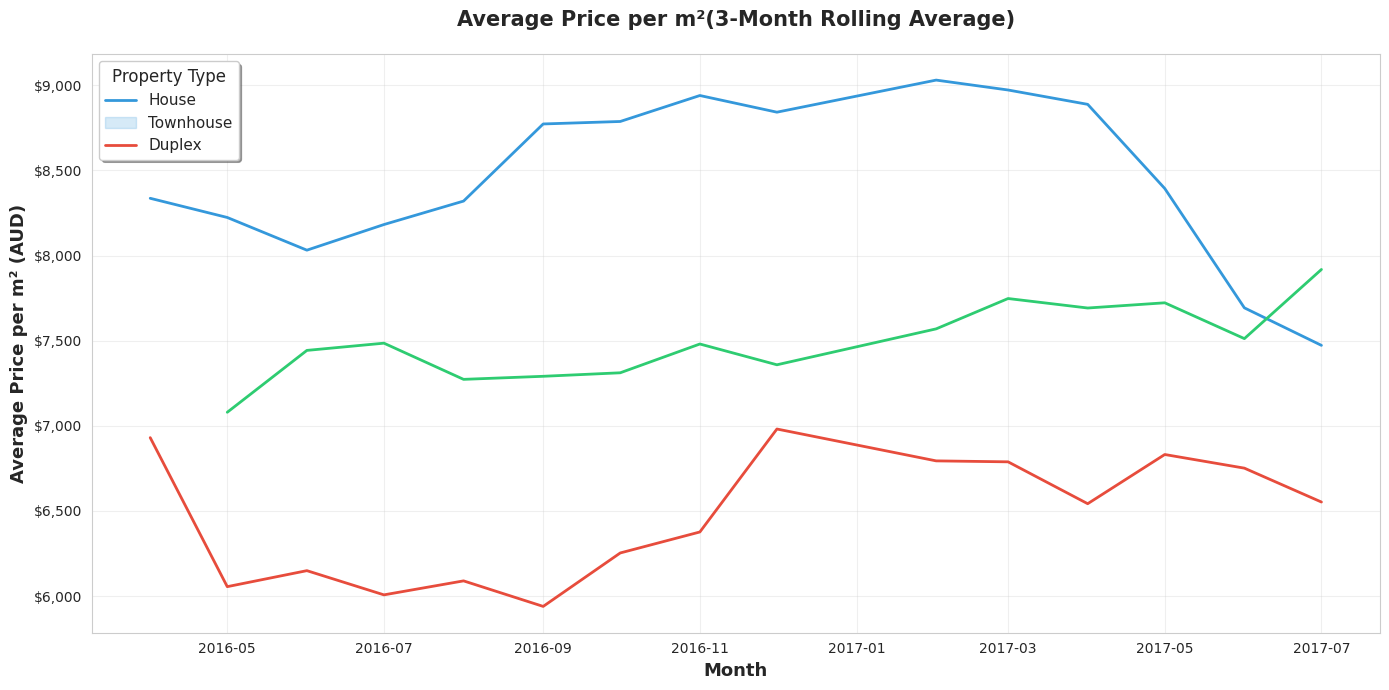

In [20]:
# average price per month and property type
average_price_by_month_type = df.groupby([df['Date'].dt.to_period('M'), 'Type'])['price_size'].mean().reset_index()

# rrolling average calculation
average_price_by_month_type['Date'] = average_price_by_month_type['Date'].astype(str)
average_price_by_month_type['Date'] = pd.to_datetime(average_price_by_month_type['Date'])

# 3-month rolling window
average_price_by_month_type['price_size_smooth'] = average_price_by_month_type.groupby('Type')['price_size'].transform(lambda x: x.rolling(window=3, center=True).mean())

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=average_price_by_month_type,
    x="Date",
    y="price_size_smooth",
    hue="Type",
    palette={'house': '#3498db', 'townhouse': '#e74c3c', 'duplex': '#2ecc71'},
    linewidth=2,
    ax=ax
)

# labels
plt.title('Average Price per m²(3-Month Rolling Average)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=13, fontweight='bold')
plt.ylabel('Average Price per m² (AUD)', fontsize=13, fontweight='bold')

# currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.legend(title='Property Type',
           labels=['House', 'Townhouse', 'Duplex'],
           fontsize=11,
           title_fontsize=12,
           frameon=True,
           shadow=True,
           loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

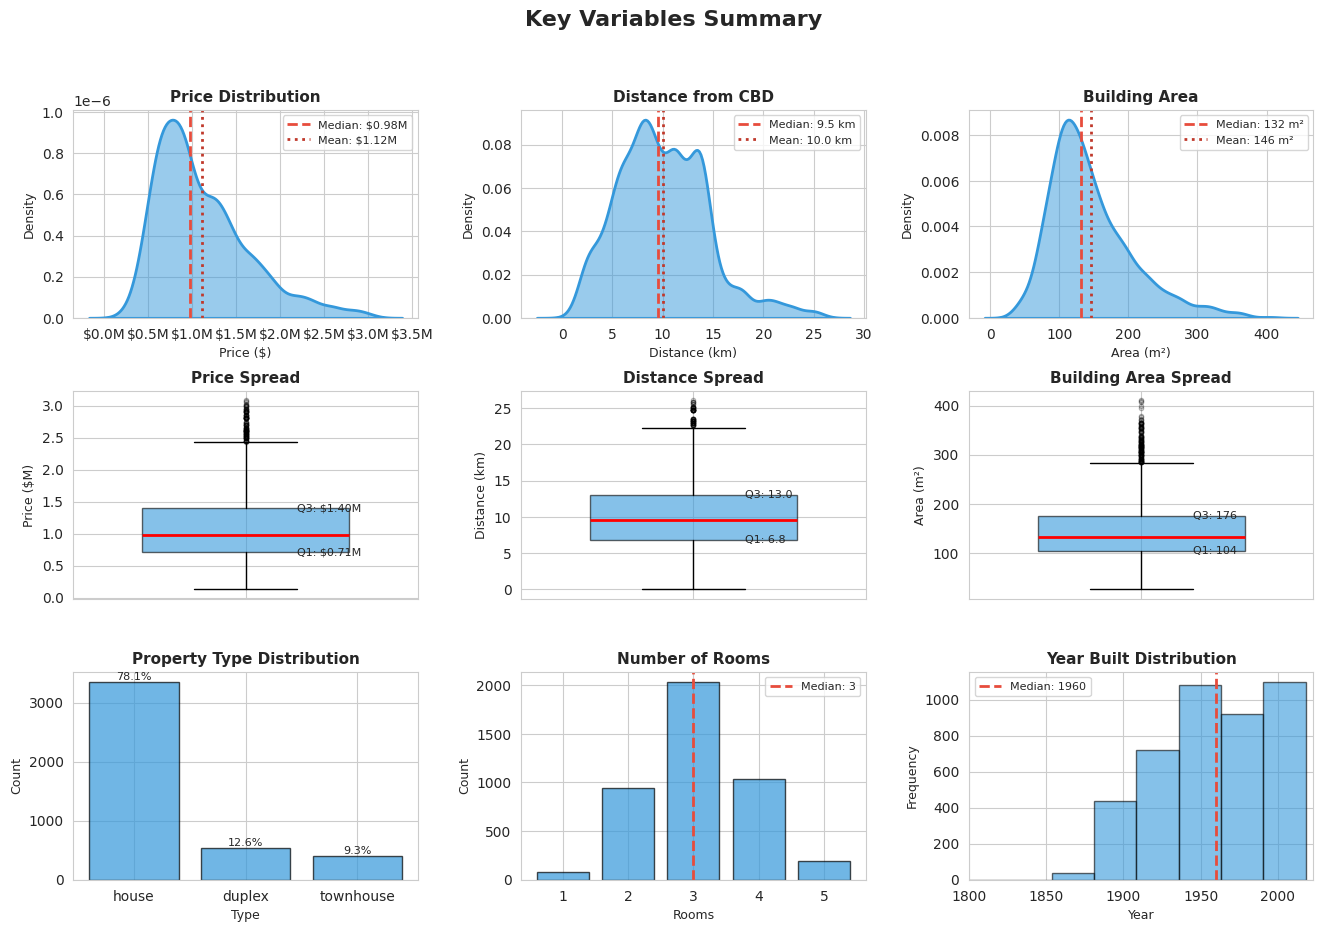

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
sns.set_style("whitegrid")

#  layout
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# title
fig.suptitle('Key Variables Summary',
             fontsize=16, fontweight='bold', y=0.98)

# blue color scheme
main_color = '#3498db'
median_color = '#e74c3c'
mean_color = '#c0392b'

# KDE plots
# Price kde
ax1 = fig.add_subplot(gs[0, 0])
sns.kdeplot(data=df, x='Price', fill=True, color=main_color, alpha=0.5, linewidth=2, ax=ax1)
ax1.axvline(df['Price'].median(), color=median_color, linestyle='--', linewidth=2, label=f'Median: ${df["Price"].median()/1e6:.2f}M')
ax1.axvline(df['Price'].mean(), color=mean_color, linestyle=':', linewidth=2, label=f'Mean: ${df["Price"].mean()/1e6:.2f}M')
ax1.set_title('Price Distribution', fontsize=11, fontweight='bold')
ax1.set_xlabel('Price ($)', fontsize=9)
ax1.set_ylabel('Density', fontsize=9)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.legend(fontsize=8, loc='upper right')

#Distance from CBD kde
ax2 = fig.add_subplot(gs[0, 1])
sns.kdeplot(data=df, x='Distance', fill=True, color=main_color, alpha=0.5, linewidth=2, ax=ax2)
ax2.axvline(df['Distance'].median(), color=median_color, linestyle='--', linewidth=2, label=f'Median: {df["Distance"].median():.1f} km')
ax2.axvline(df['Distance'].mean(), color=mean_color, linestyle=':', linewidth=2, label=f'Mean: {df["Distance"].mean():.1f} km')
ax2.set_title('Distance from CBD', fontsize=11, fontweight='bold')
ax2.set_xlabel('Distance (km)', fontsize=9)
ax2.set_ylabel('Density', fontsize=9)
ax2.legend(fontsize=8, loc='upper right')

# Building Area
ax3 = fig.add_subplot(gs[0, 2])
building_data = df['BuildingArea'].dropna()
sns.kdeplot(data=building_data, fill=True, color=main_color, alpha=0.5, linewidth=2, ax=ax3)
ax3.axvline(building_data.median(), color=median_color, linestyle='--', linewidth=2, label=f'Median: {building_data.median():.0f} m²')
ax3.axvline(building_data.mean(), color=mean_color, linestyle=':', linewidth=2, label=f'Mean: {building_data.mean():.0f} m²')
ax3.set_title('Building Area', fontsize=11, fontweight='bold')
ax3.set_xlabel('Area (m²)', fontsize=9)
ax3.set_ylabel('Density', fontsize=9)
ax3.legend(fontsize=8, loc='upper right')

# plots showing spread
# price plot
ax4 = fig.add_subplot(gs[1, 0])
box1 = ax4.boxplot([df['Price']/1e6], vert=True, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor=main_color, alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax4.set_title('Price Spread', fontsize=11, fontweight='bold')
ax4.set_ylabel('Price ($M)', fontsize=9)
ax4.set_xticklabels([''])
ax4.text(1.15, df['Price'].quantile(0.75)/1e6, f'Q3: ${df["Price"].quantile(0.75)/1e6:.2f}M',
         fontsize=8, va='center')
ax4.text(1.15, df['Price'].quantile(0.25)/1e6, f'Q1: ${df["Price"].quantile(0.25)/1e6:.2f}M',
         fontsize=8, va='center')


# disance box plot
ax5 = fig.add_subplot(gs[1, 1])
box2 = ax5.boxplot([df['Distance']], vert=True, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor=main_color, alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax5.set_title('Distance Spread', fontsize=11, fontweight='bold')
ax5.set_ylabel('Distance (km)', fontsize=9)
ax5.set_xticklabels([''])
ax5.text(1.15, df['Distance'].quantile(0.75), f'Q3: {df["Distance"].quantile(0.75):.1f}',
         fontsize=8, va='center')
ax5.text(1.15, df['Distance'].quantile(0.25), f'Q1: {df["Distance"].quantile(0.25):.1f}',
         fontsize=8, va='center')

# uilding Area Box Plot
ax6 = fig.add_subplot(gs[1, 2])
box3 = ax6.boxplot([building_data], vert=True, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor=main_color, alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax6.set_title('Building Area Spread', fontsize=11, fontweight='bold')
ax6.set_ylabel('Area (m²)', fontsize=9)
ax6.set_xticklabels([''])
ax6.text(1.15, building_data.quantile(0.75), f'Q3: {building_data.quantile(0.75):.0f}',
         fontsize=8, va='center')
ax6.text(1.15, building_data.quantile(0.25), f'Q1: {building_data.quantile(0.25):.0f}',
         fontsize=8, va='center')

# Categorical and discrete variables
# Property Type
ax7 = fig.add_subplot(gs[2, 0])
type_counts = df['Type'].value_counts()
bars = ax7.bar(type_counts.index, type_counts.values, color=main_color,
               edgecolor='black', alpha=0.7)
ax7.set_title('Property Type Distribution', fontsize=11, fontweight='bold')
ax7.set_xlabel('Type', fontsize=9)
ax7.set_ylabel('Count', fontsize=9)
# Add percentages on bars
for i, (idx, val) in enumerate(type_counts.items()):
    pct = 100 * val / len(df)
    ax7.text(i, val, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

# Rooms distribution
ax8 = fig.add_subplot(gs[2, 1])
room_counts = df['Rooms'].value_counts().sort_index()
ax8.bar(room_counts.index, room_counts.values, color=main_color,
        edgecolor='black', alpha=0.7)
ax8.set_title('Number of Rooms', fontsize=11, fontweight='bold')
ax8.set_xlabel('Rooms', fontsize=9)
ax8.set_ylabel('Count', fontsize=9)
ax8.axvline(df['Rooms'].median(), color=median_color, linestyle='--', linewidth=2,
            label=f'Median: {df["Rooms"].median():.0f}')
ax8.legend(fontsize=8)

# Year Built distribution
ax9 = fig.add_subplot(gs[2, 2])
year_data = df['YearBuilt'].dropna()
ax9.hist(year_data, bins=30, color=main_color, edgecolor='black', alpha=0.6)
ax9.axvline(year_data.median(), color=median_color, linestyle='--', linewidth=2,
            label=f'Median: {int(year_data.median())}')
ax9.set_title('Year Built Distribution', fontsize=11, fontweight='bold')
ax9.set_xlabel('Year', fontsize=9)
ax9.set_ylabel('Frequency', fontsize=9)
ax9.set_xlim(1800, year_data.max() + 5)
ax9.legend(fontsize=8)
plt.show()


### Price

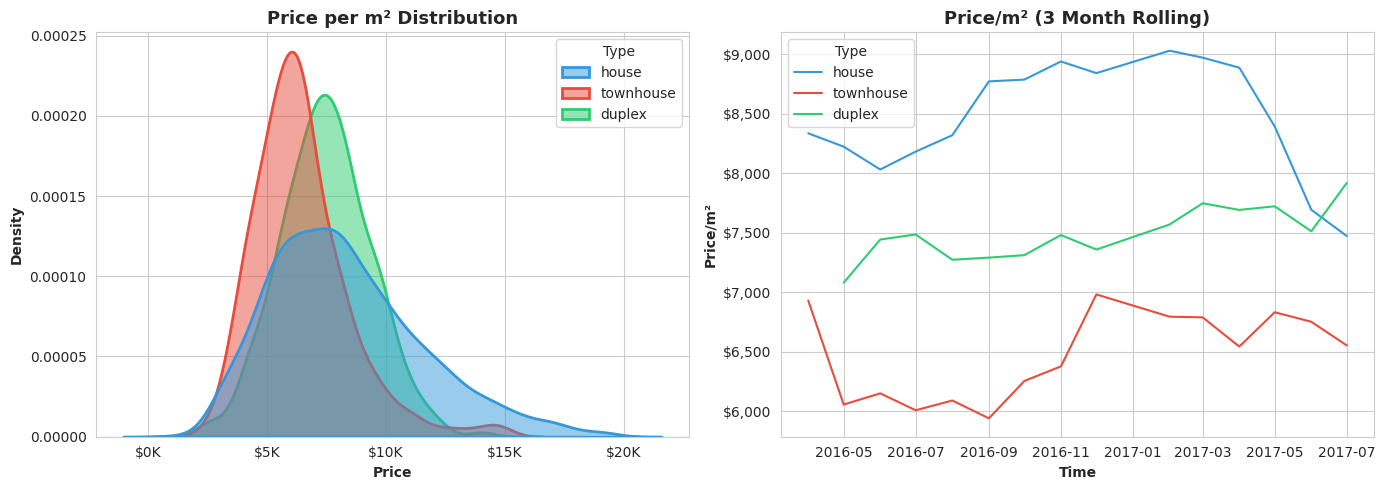

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'house': '#3498db', 'townhouse': '#e74c3c', 'duplex': '#2ecc71'}

sns.kdeplot(
    data=df,
    x="price_size",
    hue="Type",
    fill=True,
    common_norm=False,
    palette=palette,
    alpha=0.5,
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('Price per m² Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price', fontweight='bold')
axes[0].set_ylabel('Density', fontweight='bold')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)
#axes[0].legend(title='Type', fontsize=9, title_fontsize=10)

sns.lineplot(
    data=average_price_by_month_type,
    x="Date",
    y="price_size_smooth",
    hue="Type",
    palette=palette,
    ax=axes[1]
)
axes[1].set_title('Price/m² (3 Month Rolling)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time', fontweight='bold')
axes[1].set_ylabel('Price/m²', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
#axes[1].legend(title='Type', fontsize=9, title_fontsize=10)
plt.savefig('kde_and_rolling3.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()


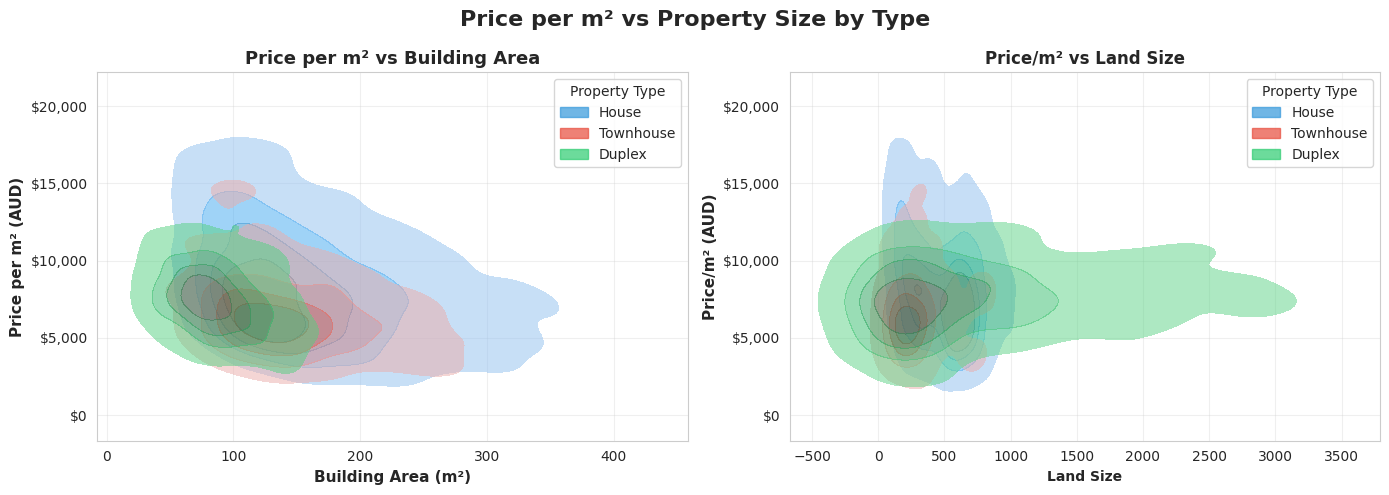

In [63]:
import matplotlib.patches as mpatches
# subplot grid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price per m² vs Property Size by Type', fontsize=16, fontweight='bold', y=0.98)

# price_size vs BuildingArea left
for prop_type, color in palette.items():
    data_subset = df[df['Type'] == prop_type].dropna(subset=['BuildingArea', 'price_size'])
    if len(data_subset) > 0:
        sns.kdeplot(
            data=data_subset,
            x='BuildingArea',
            y='price_size',
            color=color,
            alpha=0.5,
            fill=True,
            levels=5,
            ax=axes[0]
        )
axes[0].set_title('Price per m² vs Building Area', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Building Area (m²)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Price per m² (AUD)', fontsize=11, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# price_size vs Landsize
for prop_type, color in palette.items():
    data_subset = df[df['Type'] == prop_type].dropna(subset=['Landsize', 'price_size'])
    if len(data_subset) > 0:
        sns.kdeplot(
            data=data_subset,
            x='Landsize',
            y='price_size',
            color=color,
            alpha=0.5,
            fill=True,
            levels=5,
            ax=axes[1]
        )
axes[1].set_title('Price/m² vs Land Size', fontweight='bold')
axes[1].set_xlabel('Land Size', fontweight='bold')
axes[1].set_ylabel('Price/m² (AUD)', fontsize=11, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1].grid(True, alpha=0.3)

# legend
legend_handles = [
    mpatches.Patch(color=color, label=prop_type.capitalize(), alpha=0.7)
    for prop_type, color in palette.items()
]
axes[0].legend(handles=legend_handles, title='Property Type', loc='best')
axes[1].legend(handles=legend_handles, title='Property Type', loc='best')
plt.tight_layout()
plt.show()


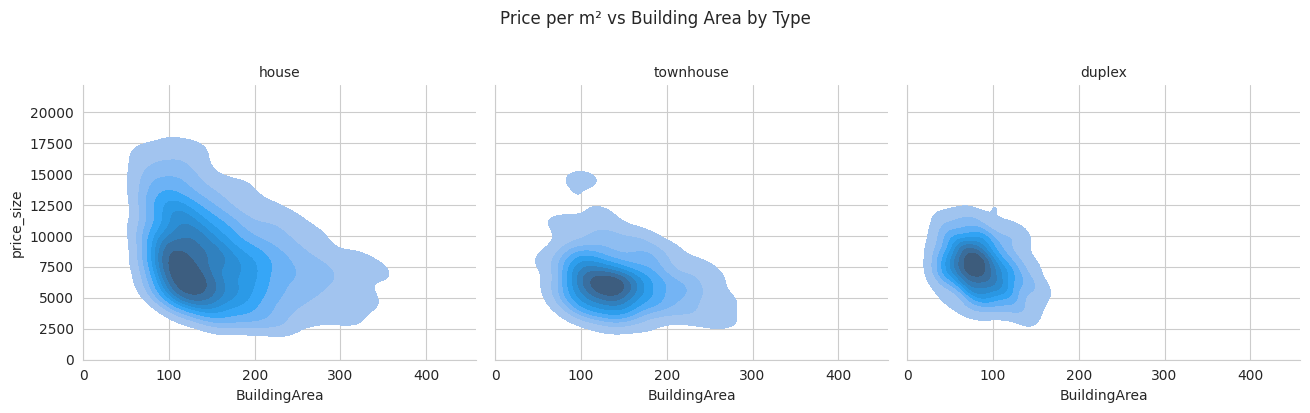

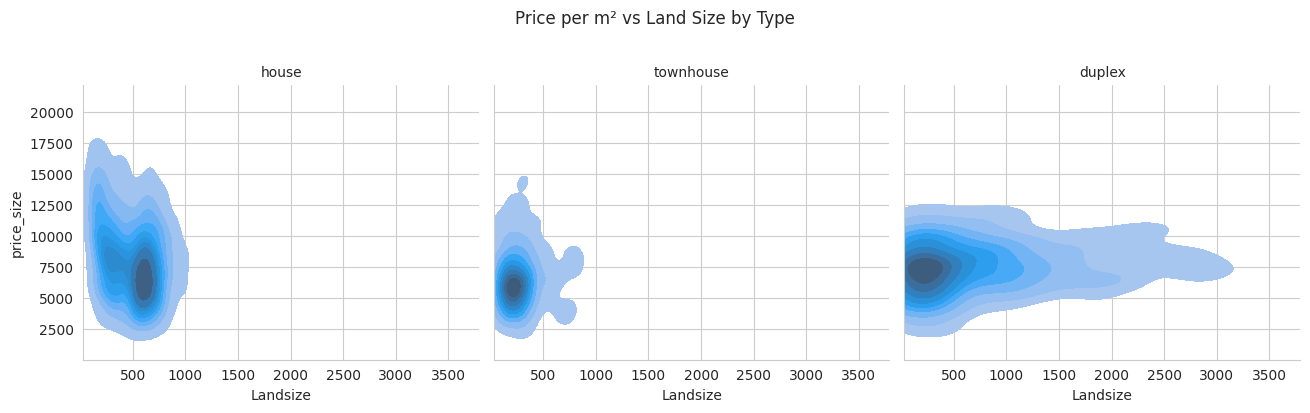

In [68]:
# Building Area
g = sns.FacetGrid(df, col="Type", col_order=["house", "townhouse", "duplex"],
                  height=4, aspect=1.1)
g.map_dataframe(sns.kdeplot, x="BuildingArea", y="price_size",
                fill=True, clip=(0, None))
g.set_titles(col_template="{col_name}")
g.figure.suptitle("Price per m² vs Building Area by Type", y=1.02)
plt.tight_layout()
plt.show()

# Land Size
g2 = sns.FacetGrid(df, col="Type", col_order=["house", "townhouse", "duplex"],
                   height=4, aspect=1.1)
g2.map_dataframe(sns.kdeplot, x="Landsize", y="price_size",
                 fill=True, clip=(30, None))
g2.set_titles(col_template="{col_name}")
g2.figure.suptitle("Price per m² vs Land Size by Type", y=1.02)
plt.tight_layout()
plt.show()

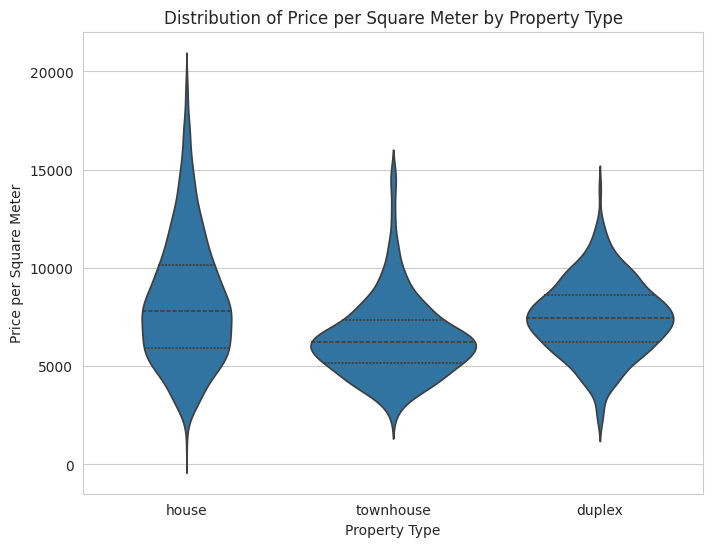

In [24]:
# Distribution of price_size for the different types of houses using boxplot
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Type', y='price_size', inner="quartile")
plt.title('Distribution of Price per Square Meter by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Price per Square Meter')
plt.show()

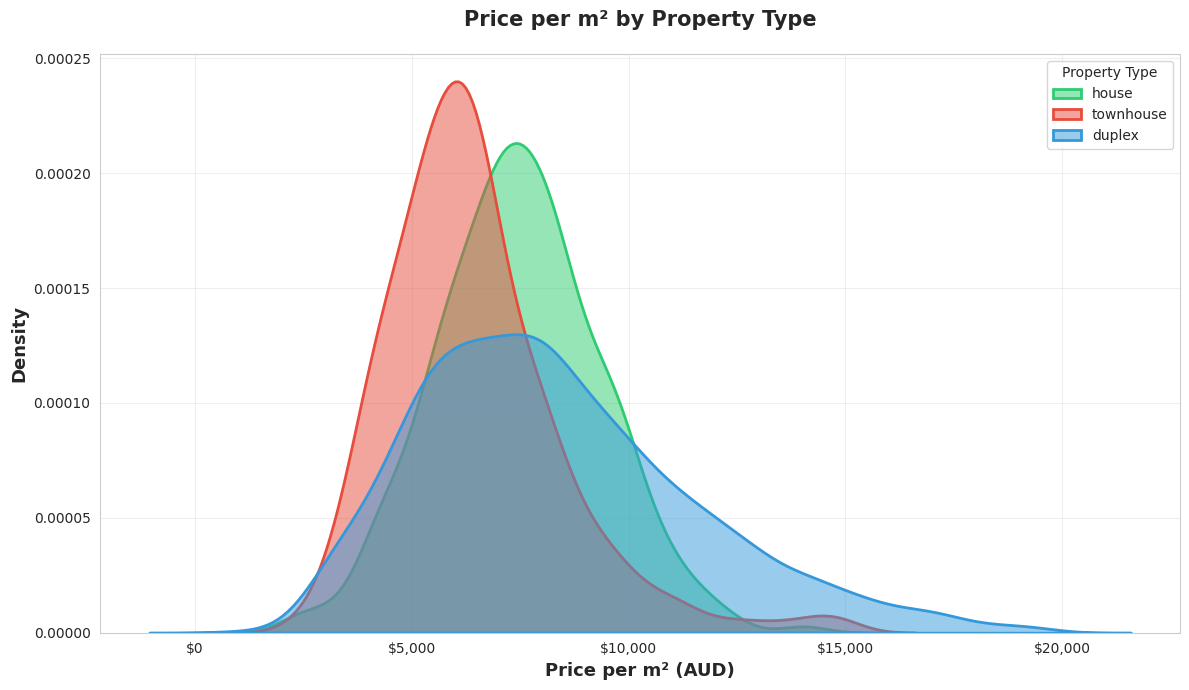

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
sns.set_style("whitegrid")

# key metrics property type
metrics = df.groupby('Type')['price_size'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std')
]).round(0)

modes = df.groupby('Type')['price_size'].apply(
    lambda x: x.value_counts().index[0] if len(x) > 0 else 0
).round(0)
metrics['Mode'] = modes

# figure
fig, ax = plt.subplots(figsize=(12, 7))

# kde plot
sns.kdeplot(
    data=df,
    x="price_size",
    hue="Type",
    fill=True,
    common_norm=False,
    palette={'house': '#3498db', 'townhouse': '#e74c3c', 'duplex': '#2ecc71'},
    alpha=0.5,
    linewidth=2,
    ax=ax
)

# labels
plt.title('Price per m² by Property Type',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Price per m² (AUD)', fontsize=13, fontweight='bold')
plt.ylabel('Density', fontsize=13, fontweight='bold')
ax.legend(title='Property Type', labels=df['Type'].unique())

# axis as currency
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.savefig('kde_price.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()


In [26]:
# metrics for the 3 differnt housing types
house_metrics = df[df['Type'] == 'house'].describe()
townhouse_metrics = df[df['Type'] == 'townhouse'].describe()
duplex_metrics = df[df['Type'] == 'duplex'].describe()

display(house_metrics['price_size'])
display(townhouse_metrics['price_size'])
display(duplex_metrics['price_size'])



,price_size
count,3359.000000
mean,8295.745758
min,845.000000
25%,5907.500000
50%,7824.000000
75%,10150.500000
max,19688.000000
std,3213.600374


,price_size
count,401.000000
mean,6413.738155
min,2528.000000
25%,5145.000000
50%,6209.000000
75%,7350.000000
max,14808.000000
std,2002.484960


,price_size
count,540.000000
mean,7460.212963
min,2267.000000
25%,6241.750000
50%,7448.000000
75%,8630.500000
max,14130.000000
std,1888.821914


In [27]:
# calculate council area metrics
council_area_metrics = (
    df.groupby('CouncilArea')
      .agg(
          average_landsize=('Landsize', 'mean'),
          average_building_area=('BuildingArea', 'mean'),
          average_bathrooms=('Bathroom', 'mean'),
          average_cars=('Car', 'mean'),
          average_distance=('Distance', 'mean'),
          average_price_size=('price_size', 'mean'),
          number_of_sales=('price_size', 'count'),
          median_type=('Type', lambda x: x.mode().iat[0] if not x.mode().empty else None)
      )
      .reset_index()
)

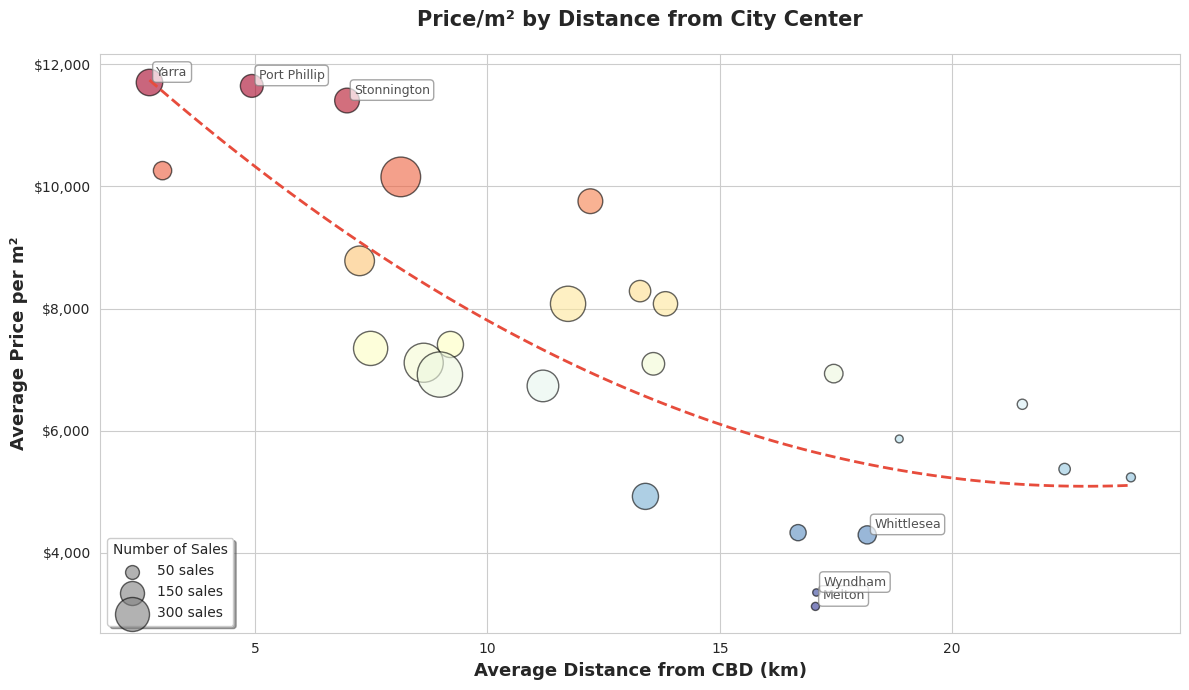

In [28]:

# price/m**2 by distance
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot
scatter = ax.scatter(council_area_metrics['average_distance'],
                     council_area_metrics['average_price_size'],
                     s=council_area_metrics['number_of_sales'] * 2,  # Size by sales volume
                     alpha=0.6,
                     c=council_area_metrics['average_price_size'],
                     cmap = plt.cm.RdYlBu_r,
                     #color="#2ecc71",
                     edgecolors='black',
                     linewidth=1)

# regression line
sns.regplot(data=council_area_metrics,
            x='average_distance',
            y='average_price_size',
            scatter=False,
            order=2,
            ci=None,
            line_kws={'color': '#e74c3c', 'linewidth': 2, 'linestyle': '--'},
            ax=ax)

# top/bottom 3 by price
top_3 = council_area_metrics.nlargest(3, 'average_price_size')
bottom_3 = council_area_metrics.nsmallest(3, 'average_price_size')
labeled = pd.concat([top_3, bottom_3])

for idx, row in labeled.iterrows(): # not needed
    ax.annotate(row['CouncilArea'],
                xy=(row['average_distance'], row['average_price_size']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))

# labels
ax.set_xlabel('Average Distance from CBD (km)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price per m²', fontsize=13, fontweight='bold')
ax.set_title('Price/m² by Distance from City Center',
             fontsize=15, fontweight='bold', pad=20)

# currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# legend for bubble size
# "dummy scatter plots for legend"
sizes = [50, 150, 300]
labels = ['50 sales', '150 sales', '300 sales']
legend_elements = [plt.scatter([], [], s=s*2, c='gray', alpha=0.6, edgecolors='black', linewidth=1)
                   for s in sizes]
legend1 = ax.legend(legend_elements, labels,
                    loc='lower left', title='Number of Sales',
                    frameon=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()



In [29]:
corr_matrix["price_size"].sort_values(ascending=False)
# buidling area, price not relevant

,price_size
price_size,1.000000
Price,0.548132
Longtitude,0.171204
Propertycount,0.170081
Landsize,-0.082820
Car,-0.176386
Bathroom,-0.178445
Rooms,-0.186200
BuildingArea,-0.277457
Lattitude,-0.324861


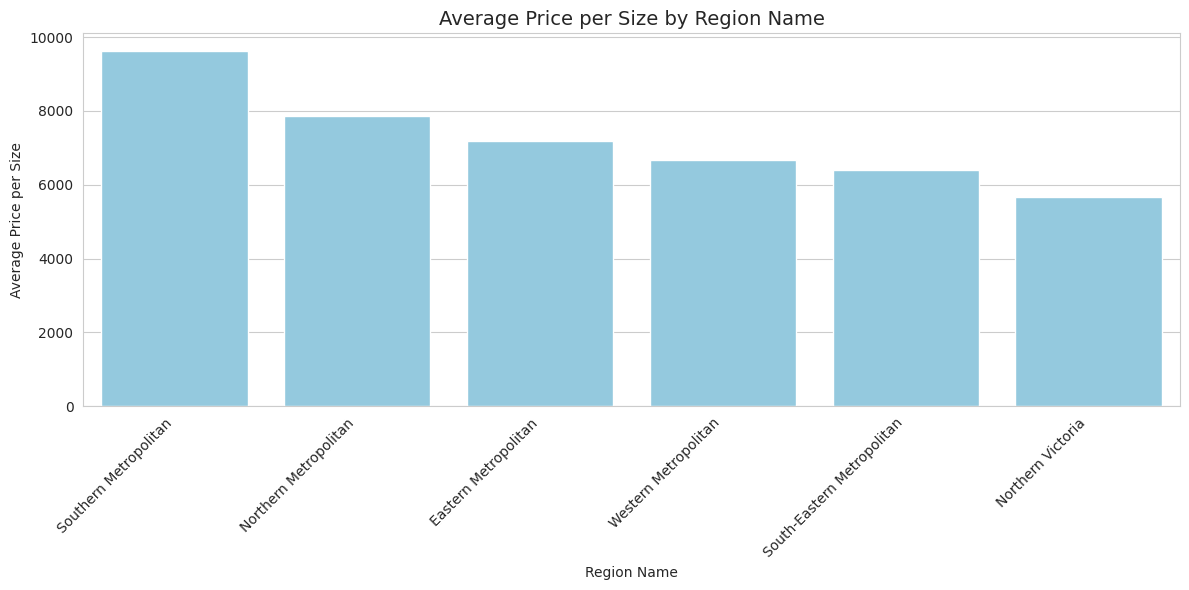

In [30]:
# average price_size per region
average_price_by_region = (
    df.groupby('Regionname')['price_size']
      .mean()
      .reset_index()
      .sort_values('price_size', ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=average_price_by_region,
    x='Regionname', y='price_size',
    color='skyblue'
)
plt.title('Average Price per Size by Region Name', fontsize=14)
plt.xlabel('Region Name')
plt.ylabel('Average Price per Size')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Rooms, Bedroom, Bathroom

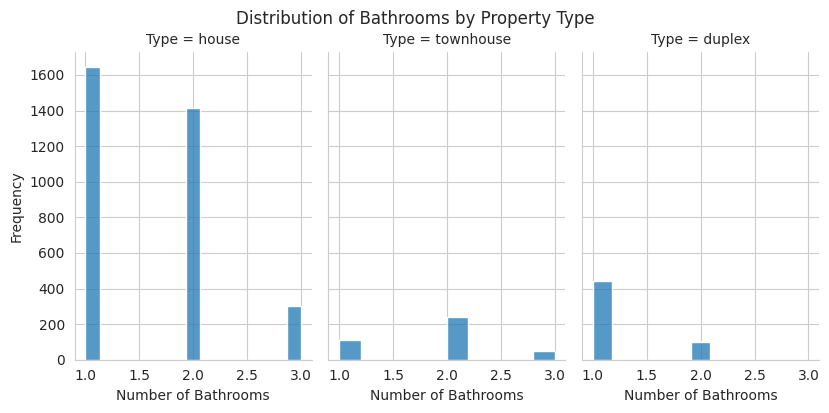

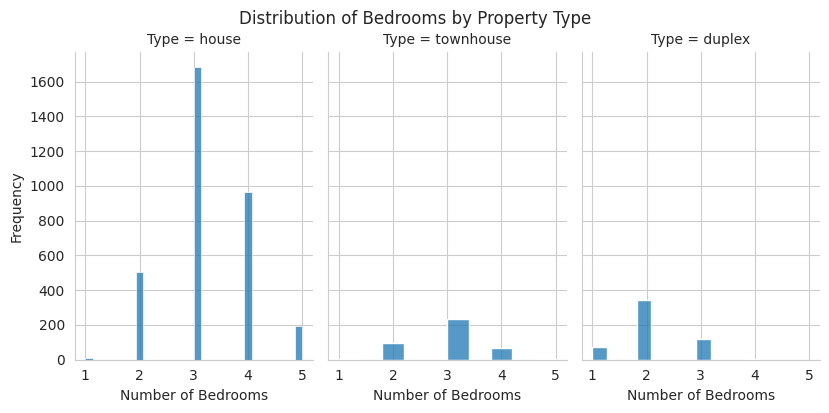

In [31]:
# bathroom
sns.set_style("whitegrid")
g = sns.FacetGrid(df, col="Type", height=4, aspect=.7)
g.map(sns.histplot, "Bathroom")
g.fig.suptitle('Distribution of Bathrooms by Property Type', y=1.02)
g.set_axis_labels('Number of Bathrooms', 'Frequency')

plt.show()

# bedroom
sns.set_style("whitegrid")
g = sns.FacetGrid(df, col="Type", height=4, aspect=.7)
g.map(sns.histplot, "Rooms")
g.fig.suptitle('Distribution of Bedrooms by Property Type', y=1.02)
g.set_axis_labels('Number of Bedrooms', 'Frequency')
plt.show()


<Axes: xlabel='Method', ylabel='price_size'>

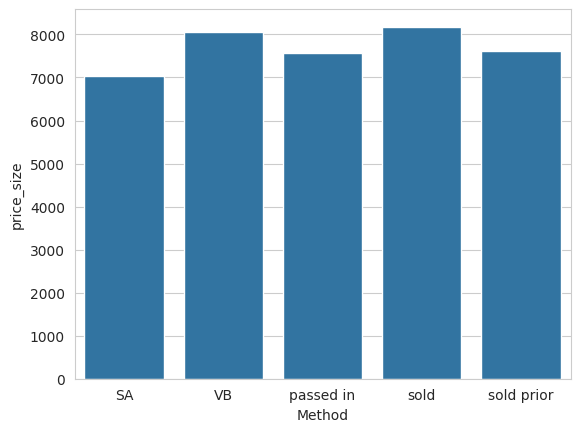

In [32]:
# average price_size per by how it was sold
sns.set_style("whitegrid")
avg_price_size_method = df.groupby('Method')['price_size'].mean().reset_index()
sns.barplot(data=avg_price_size_method, x='Method', y='price_size')

### Houses
 t  = townhouse
 u = duplex
 h = house

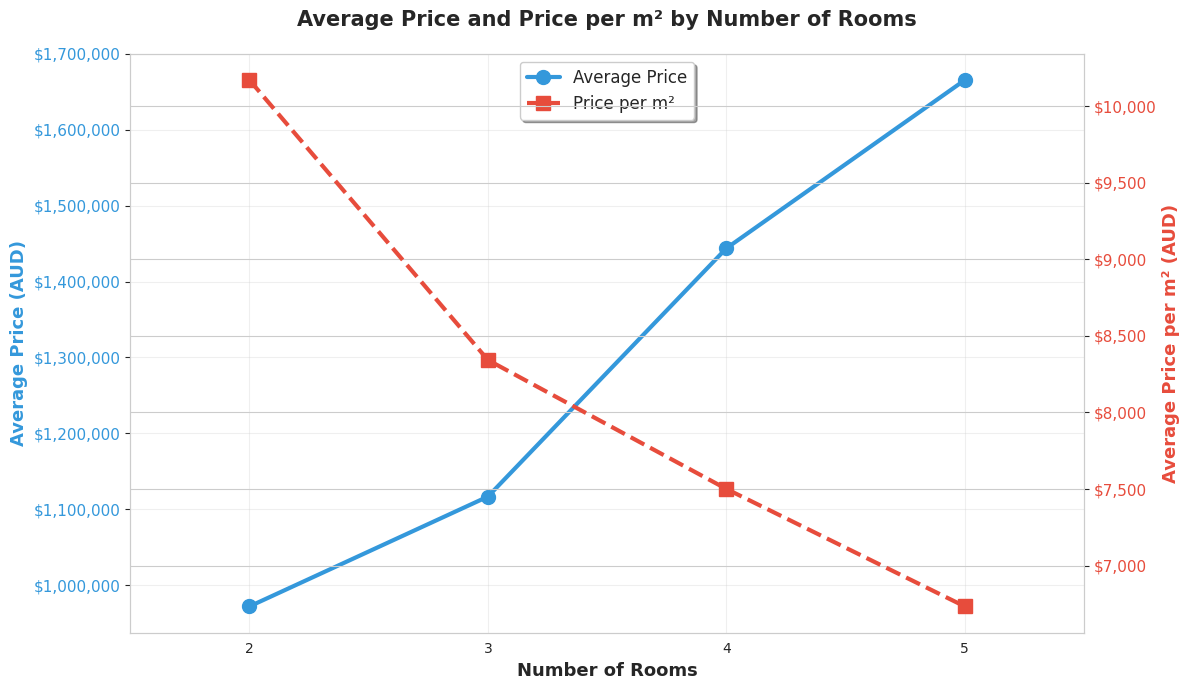

In [33]:
df_house = df[df['Type'] == 'house'].copy()
df_house = df_house[df_house['Rooms'] > 1].copy()

# average price per number of rooms for 'house' type
room_metrics = df_house.groupby('Rooms').agg(
    average_price=('Price', 'mean'),
    average_price_size=('price_size', 'mean'),
    number_of_properties=('Price', 'count')
).reset_index()

sns.set_style("whitegrid")

# second y-axis
fig, ax1 = plt.subplots(figsize=(12, 7))

#average price on the primary y-axis
line1 = ax1.plot(room_metrics['Rooms'], room_metrics['average_price'],
                 marker='o', linewidth=3, markersize=10,
                 color='#3498db', label='Average Price', zorder=3)
ax1.set_xlabel('Number of Rooms', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Price (AUD)', fontsize=13, fontweight='bold', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db', labelsize=11)
ax1.grid(True, alpha=0.3, zorder=1)

# currency
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# only integer room values?
ax1.set_xticks(room_metrics['Rooms'])
ax1.set_xlim(room_metrics['Rooms'].min() - 0.5, room_metrics['Rooms'].max() + 0.5)


#  yaxis for average price per square meter
ax2 = ax1.twinx()
line2 = ax2.plot(room_metrics['Rooms'], room_metrics['average_price_size'],
                 marker='s', linewidth=3, markersize=10,
                 color='#e74c3c', label='Price per m²', linestyle='--', zorder=3)
ax2.set_ylabel('Average Price per m² (AUD)', fontsize=13, fontweight='bold', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c', labelsize=11)

# secondary y-axis currency
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

ax1.set_title('Average Price and Price per m² by Number of Rooms',
              fontsize=15, fontweight='bold', pad=20)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', fontsize=12, frameon=True, # loc: auto?
           shadow=True, fancybox=True)

plt.tight_layout()
plt.show()

In [34]:
# absolut numbers of sales per type in council
sales_per_type = df.groupby(['CouncilArea', 'Type']).size().unstack(fill_value=0)

# average distance from CBD per council
average_distance_by_council = df.groupby('CouncilArea')['Distance'].mean()

sales_per_type_with_distance = sales_per_type.merge(average_distance_by_council, left_index=True, right_index=True, how='left')

# distance
sales_per_type_with_distance.rename(columns={'Distance': 'average_distance_from_CBD'}, inplace=True)

display(sales_per_type_with_distance.round(2).sort_values(by='average_distance_from_CBD', ascending=False))

,duplex,house,townhouse,average_distance_from_CBD
CouncilArea,,,,
Greater Dandenong,2,19,0,23.85
Knox,4,26,4,22.42
Maroondah,1,25,1,21.51
Nillumbik,0,16,0,18.86
Whittlesea,5,78,3,18.17
Kingston,7,68,14,17.45
Wyndham,1,13,0,17.08
Melton,0,17,0,17.06
Hume,2,63,3,16.69


In [35]:
# most frequent type of house, average distance to CBD per region
region_metrics = df.groupby('Regionname').agg(
    most_frequent_type=('Type', lambda x: x.mode()[0] if not x.mode().empty else None),
    average_distance=('Distance', 'mean')
).reset_index()

display(region_metrics)

,Regionname,most_frequent_type,average_distance
0,Eastern Metropolitan,house,13.416265
1,Northern Metropolitan,house,8.570516
2,Northern Victoria,house,23.900000
3,South-Eastern Metropolitan,house,20.015464
4,Southern Metropolitan,house,9.611254
5,Western Metropolitan,house,9.593917


In [36]:
# average building size by suburb and by area
building_size_by_suburb = df.groupby('Suburb')['BuildingArea'].mean().sort_values(ascending=False)
building_size_by_area = df.groupby('CouncilArea')['BuildingArea'].mean().sort_values(ascending=False)

# average landsize by surburb and area
landsize_by_suburb = df.groupby('Suburb')['Landsize'].mean().sort_values(ascending=False)
landsize_by_area = df.groupby('CouncilArea')['Landsize'].mean().sort_values(ascending=False)

landsize_by_area

,Landsize
CouncilArea,
Nillumbik,785.750000
Maroondah,627.851852
Manningham,623.757576
Knox,611.500000
Greater Dandenong,584.809524
Boroondara,578.382353
Hume,575.279412
Banyule,563.208494
Melton,559.470588


### Time Relevant

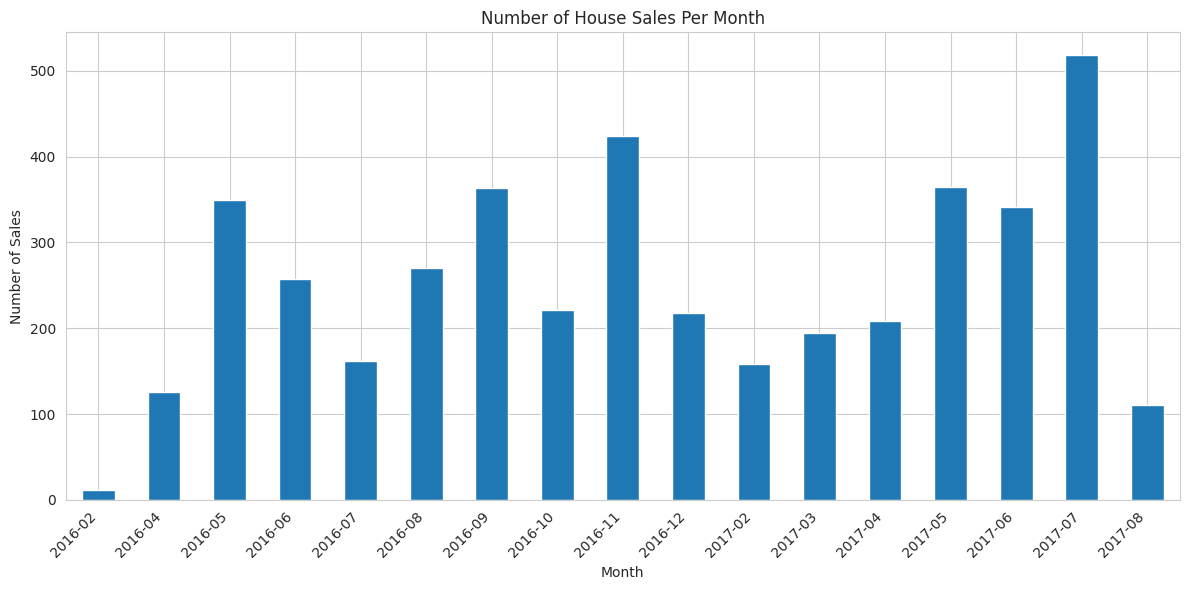

In [37]:
#  number of sales per month
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df['Month'].value_counts().sort_index()

# number of sales per month
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar')
plt.title('Number of House Sales Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# highest number of sales
most_sales_date = df['Date'].value_counts().idxmax()
max_sales_count = df['Date'].value_counts().max()

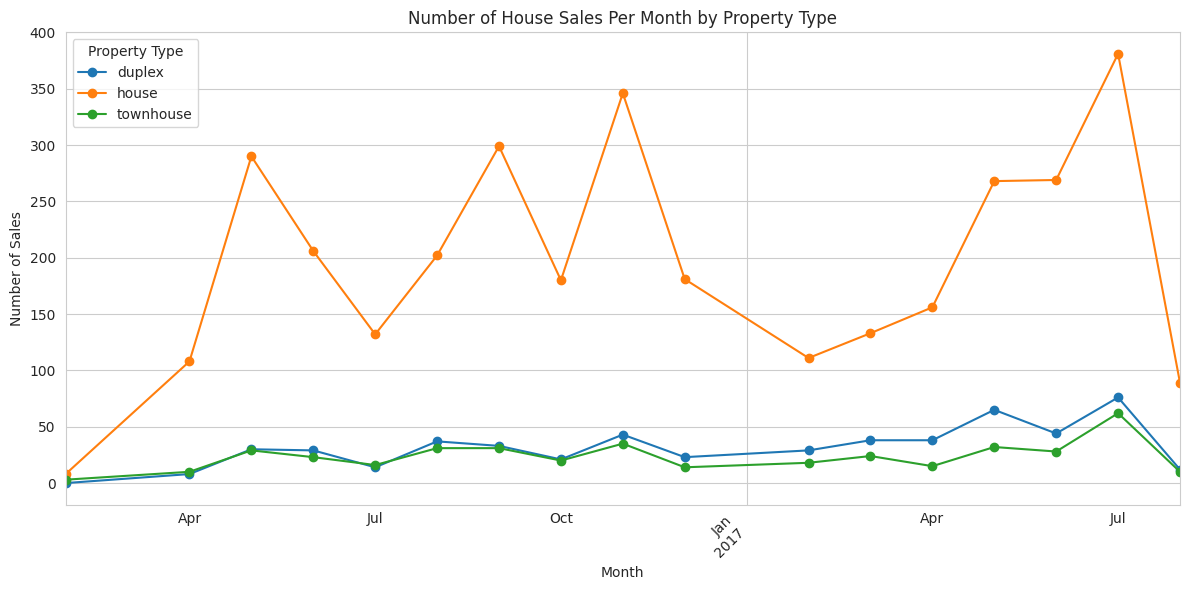

In [38]:
# number of sales per month for each property type
monthly_sales_by_type = df.groupby(['Month', 'Type']).size().unstack(fill_value=0)

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
monthly_sales_by_type.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Number of House Sales Per Month by Property Type')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Property Type')
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
# average of cols_against_price columns per month
cols_to_analyze = ["Rooms", "Distance", "Bathroom", "Car", "Propertycount", "YearBuilt", "Landsize", "price_size"]
monthly_averages = df.groupby('Date')[cols_to_analyze].mean()

display(monthly_averages.head())

,Rooms,Distance,Bathroom,Car,Propertycount,YearBuilt,Landsize,price_size
Date,,,,,,,,
2016-02-04,2.727273,10.281818,1.545455,1.636364,6222.000000,1983.909091,383.818182,8404.181818
2016-04-16,3.000000,8.898901,1.560440,1.461538,6877.516484,1947.582418,471.153846,8155.318681
2016-04-23,3.000000,9.000000,1.428571,1.342857,6666.400000,1950.571429,397.771429,7852.000000
2016-05-07,2.990654,9.273832,1.542056,1.485981,6446.728972,1951.140187,491.046729,8477.878505
2016-05-14,2.970588,8.526471,1.588235,1.411765,7425.235294,1958.397059,392.411765,7600.691176


##### YearBuilt


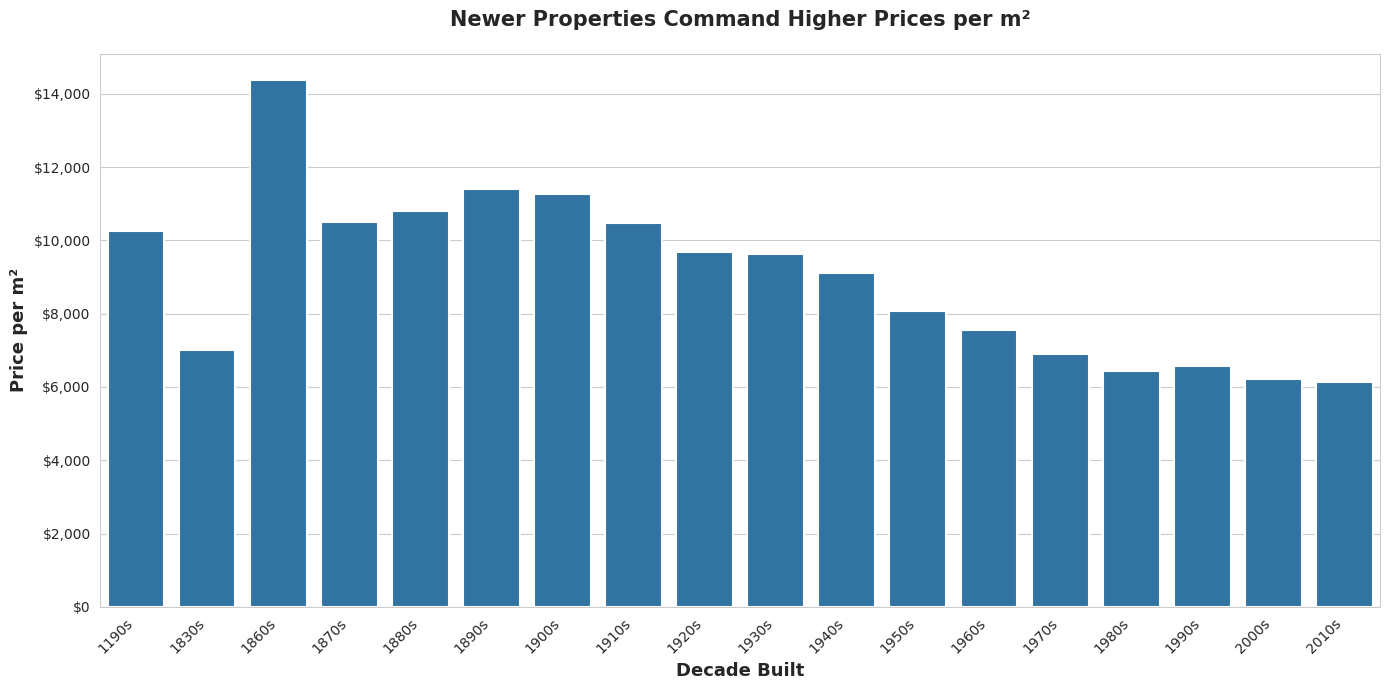

In [40]:
#decade bins
df['Decade'] = (df['YearBuilt'] // 10) * 10
df['Decade_label'] = df['Decade'].astype(int).astype(str) + 's'
df_sorted = df.sort_values('Decade')

# plot
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=df_sorted,
            x='Decade_label',
            y='price_size',
            ax=ax,
            errorbar=None,
            linewidth=1.5)

ax.set_xlabel('Decade Built', fontsize=13, fontweight='bold')
ax.set_ylabel('Price per m²', fontsize=13, fontweight='bold')
ax.set_title('Newer Properties Command Higher Prices per m²',
             fontsize=15, fontweight='bold', pad=20)

# currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

#
plt.xticks(rotation=45, ha='right')
plt.savefig('age_m2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

#files.download('age_m2.png')

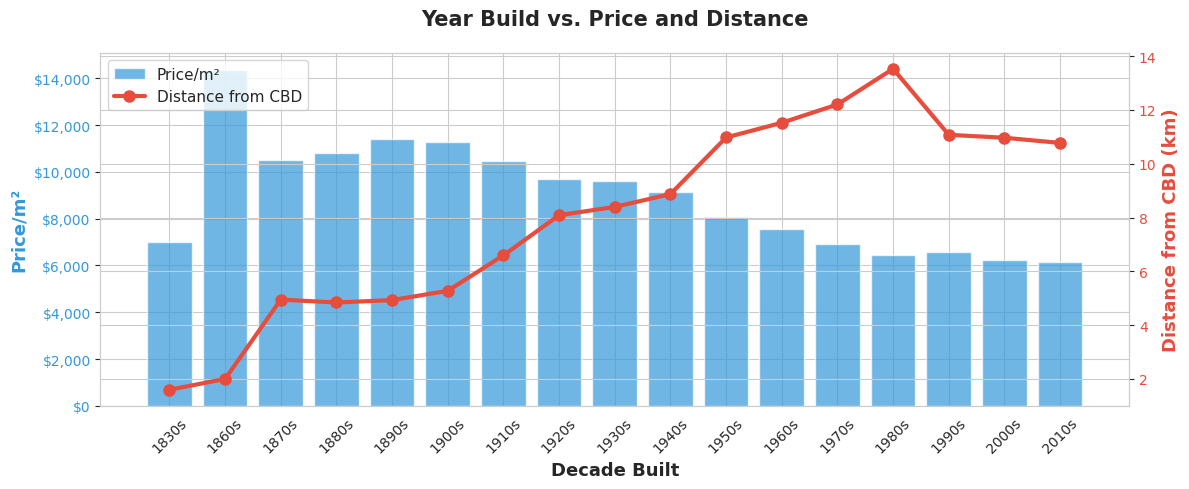

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
sns.set_style("whitegrid")

decade_order = [d for d in sorted(df['Decade_label'].unique()) if d != '1190s']

fig, ax1 = plt.subplots(figsize=(12, 5))

# price per m², left axis
color1 = '#3498db'
ax1.set_xlabel('Decade Built', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price/m²', fontsize=13, fontweight='bold', color=color1)
bars1 = ax1.bar(
    decade_order,
    df.groupby('Decade_label')['price_size'].mean().reindex(decade_order),
    color=color1,
    alpha=0.7,
    label='Price/m²'
)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# distance, right axis
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Distance from CBD (km)', fontsize=13, fontweight='bold', color=color2)
line = ax2.plot(
    decade_order,
    df.groupby('Decade_label')['Distance'].mean().reindex(decade_order),
    color=color2,
    marker='o',
    linewidth=3,
    markersize=8,
    label='Distance from CBD'
)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Year Build vs. Price and Distance',
          fontsize=15, fontweight='bold', pad=20)

# both legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

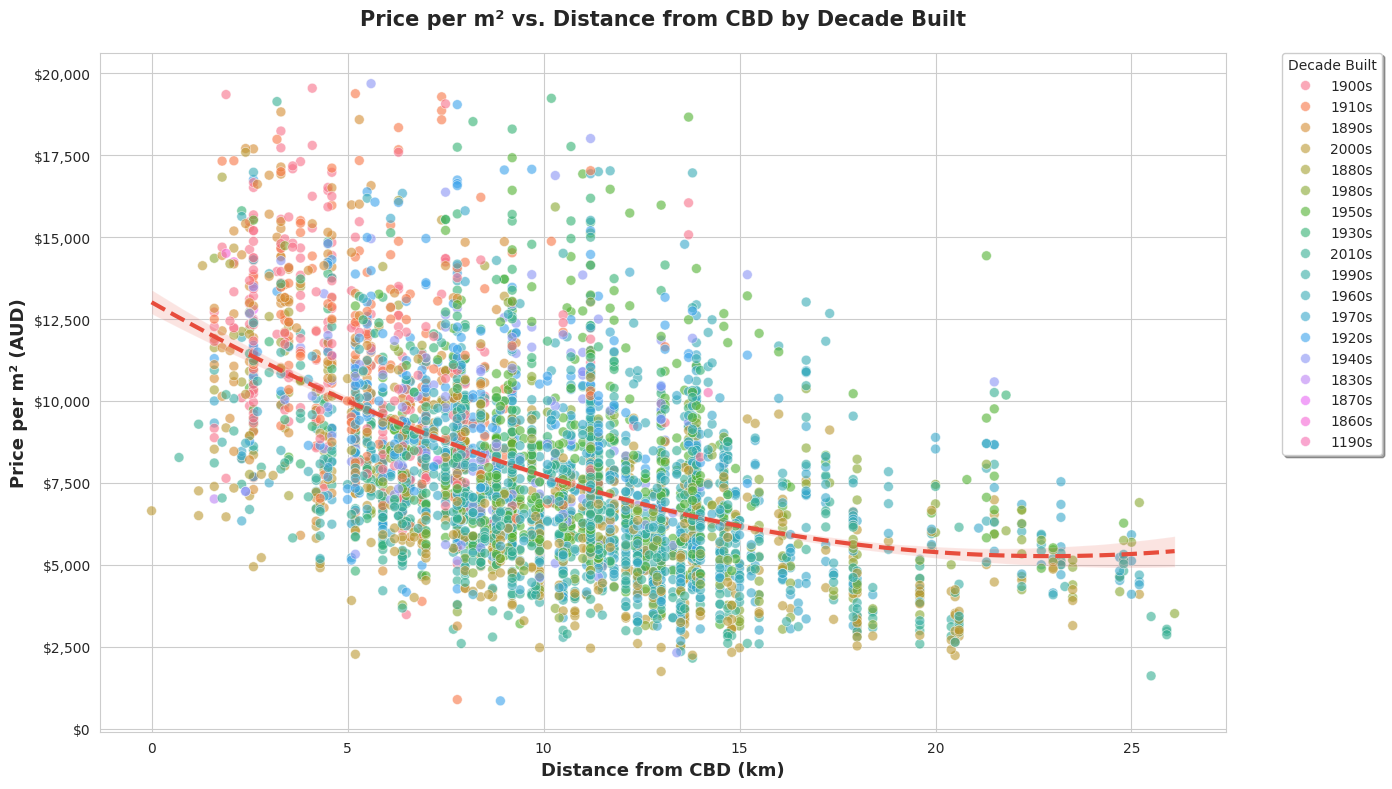

In [42]:
sns.set_style("whitegrid")

plt.figure(figsize=(14, 8))

# price_size vs Distance,  by Decade_label
scatter = sns.scatterplot(data=df,
                          x='Distance',
                          y='price_size',
                          hue='Decade_label', # labels not year
                          s=50, # Point size
                          alpha=0.6,
                          edgecolor='w',
                          linewidth=0.5)

# regression
sns.regplot(data=df,
            x='Distance',
            y='price_size',
            scatter=False,
            order=2,
            line_kws={'color': '#e74c3c', 'linewidth': 3, 'linestyle': '--'},
            ax=scatter.axes) # axes - scatterplot

plt.xlabel('Distance from CBD (km)', fontsize=13, fontweight='bold')
plt.ylabel('Price per m² (AUD)', fontsize=13, fontweight='bold')
plt.title('Price per m² vs. Distance from CBD by Decade Built',
             fontsize=15, fontweight='bold', pad=20)

# currency
scatter.axes.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# legend out of plot
plt.legend(title='Decade Built', bbox_to_anchor=(1.05, 1), loc='upper left',
           borderaxespad=0., frameon=True, shadow=True)

plt.tight_layout()
plt.show()


### Regional Patterns

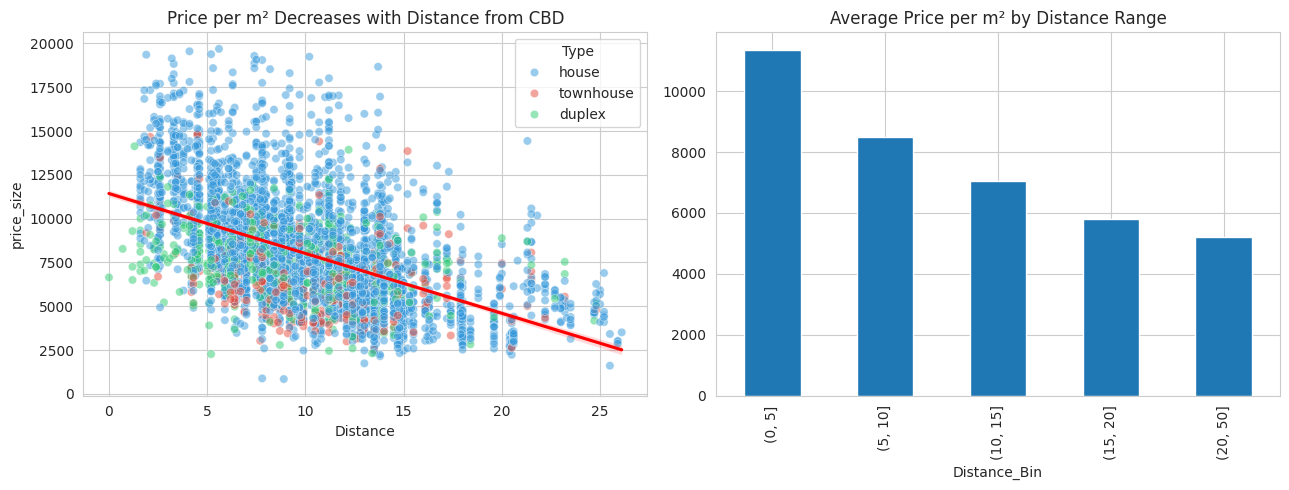

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.set_style("whitegrid")

#  with regression
sns.scatterplot(data=df, x='Distance', y='price_size', hue='Type',
                palette=palette, alpha=0.5, ax=axes[0])
sns.regplot(data=df, x='Distance', y='price_size',
            scatter=False, color='red', ax=axes[0])
axes[0].set_title('Price per m² Decreases with Distance from CBD')

# binned averages
df['Distance_Bin'] = pd.cut(df['Distance'], bins=[0, 5, 10, 15, 20, 50])
df.groupby('Distance_Bin')['price_size'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Price per m² by Distance Range')

plt.tight_layout()
plt.show()


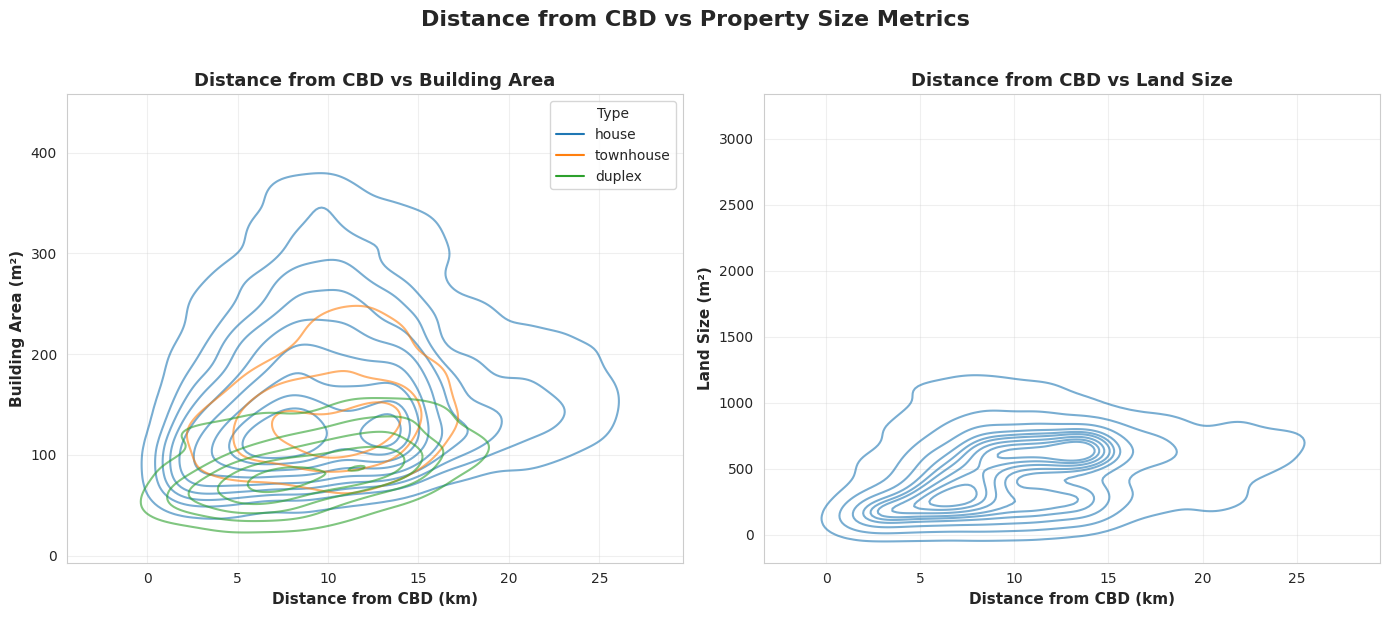

In [44]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distance from CBD vs Property Size Metrics', fontsize=16, fontweight='bold', y=1.02)

# Distance vs BuildingArea left
sns.kdeplot(data=df, x='Distance', y='BuildingArea', hue="Type", alpha=0.6, ax=axes[0])
axes[0].set_title('Distance from CBD vs Building Area', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Distance from CBD (km)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Building Area (m²)', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Distance vs Landsize right
sns.kdeplot(data=df, x='Distance', y='Landsize', alpha=0.6, ax=axes[1])
axes[1].set_title('Distance from CBD vs Land Size', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Distance from CBD (km)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Land Size (m²)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# most sales per suburb
sales_per_area = df['CouncilArea'].value_counts()
#display(sales_per_area)

In [46]:
# average distance by area towards the business district
average_distance_by_council = df.groupby('CouncilArea')['Distance'].mean().sort_values()
display(average_distance_by_council)

,Distance
CouncilArea,
Yarra,2.728022
Melbourne,3.009195
Port Phillip,4.930147
Stonnington,6.979245
Darebin,7.250439
Maribyrnong,7.486799
Boroondara,8.136029
Moonee Valley,8.629293
Moreland,8.978154


In [47]:
# average sales price per area/council
sales_per_area = df.groupby('CouncilArea')['price_size'].mean().sort_values(ascending=False)

# average sales price per postal code
sales_per_postal = df.groupby('Postcode')['price_size'].mean().sort_values(ascending=False)

sales_per_area.round(0)

,price_size
CouncilArea,
Yarra,11703.0
Port Phillip,11647.0
Stonnington,11408.0
Melbourne,10260.0
Boroondara,10157.0
Bayside,9759.0
Darebin,8782.0
Whitehorse,8287.0
Monash,8079.0


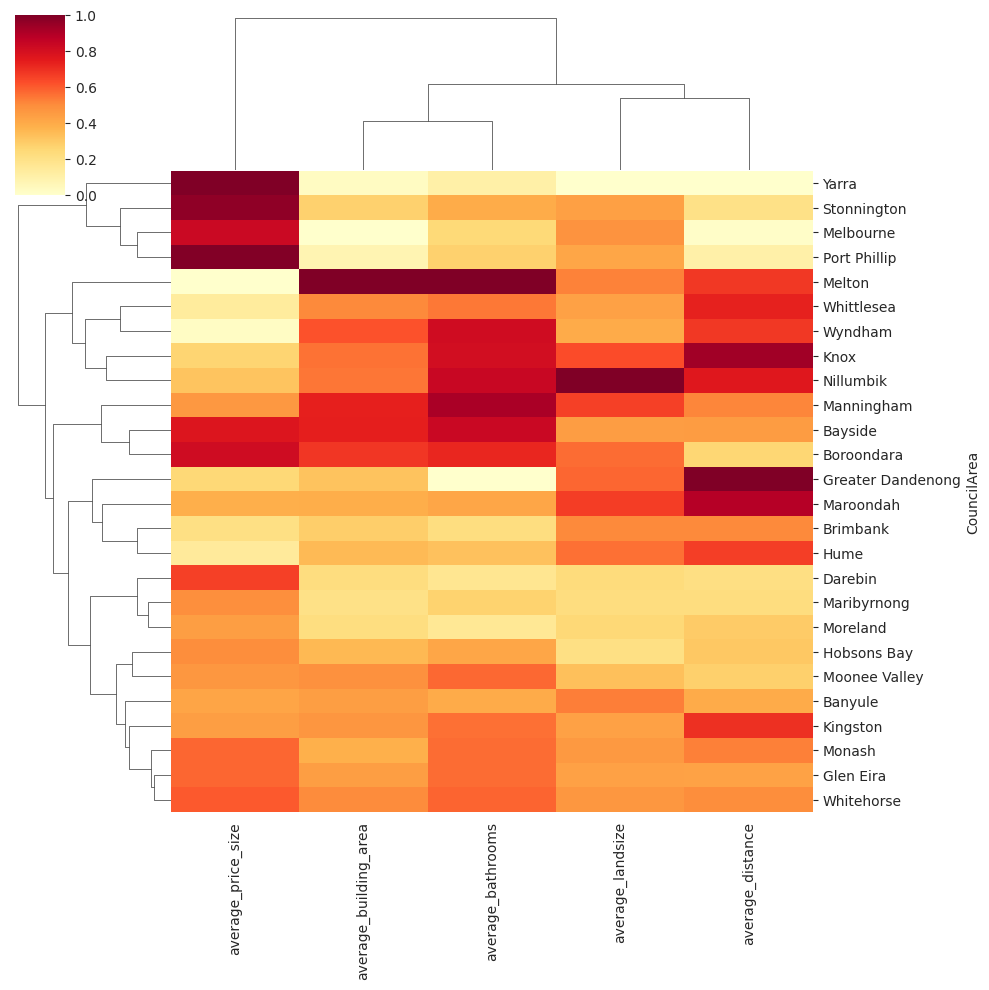

In [48]:
# cluster map, averages by council
sns.clustermap(
    council_area_metrics.set_index('CouncilArea')[['average_landsize', 'average_building_area',
                                                   'average_bathrooms',
                                                  'average_distance', 'average_price_size']],
    cmap='YlOrRd', standard_scale=1
)


In [49]:
# verage price and price size per property type
type_summary = (
    df.groupby('Type')
      .agg(
          average_price_size=('price_size', 'mean'),
          number_of_sales=('Price', 'count')
      )
      .reset_index()
      .sort_values('average_price_size', ascending=False)
)

display(type_summary)

,Type,average_price_size,number_of_sales
1,house,8295.745758,3359
0,duplex,7460.212963,540
2,townhouse,6413.738155,401


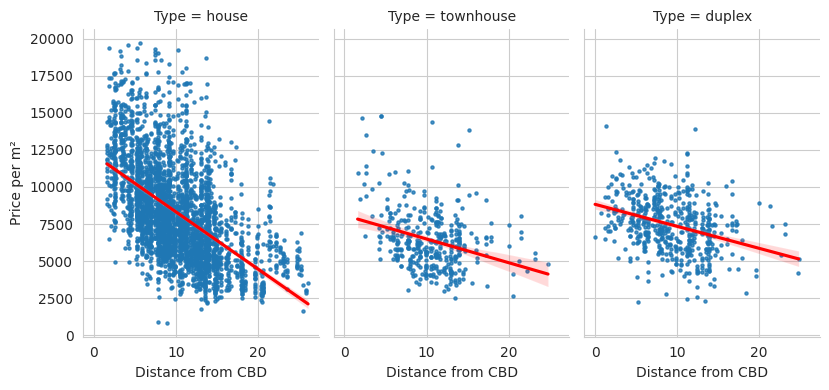

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
# price_size and distance for each property
g = sns.FacetGrid(df, col='Type', height=4, aspect=.7)
g.map(sns.regplot, 'Distance', 'price_size',scatter_kws={'s': 5},
      line_kws={'color':'red'})
#g.fig.suptitle('Price per m² vs. Distance from CBD', y=1.02)
g.set_axis_labels('Distance from CBD', 'Price per m²')
plt.tight_layout()
plt.show()

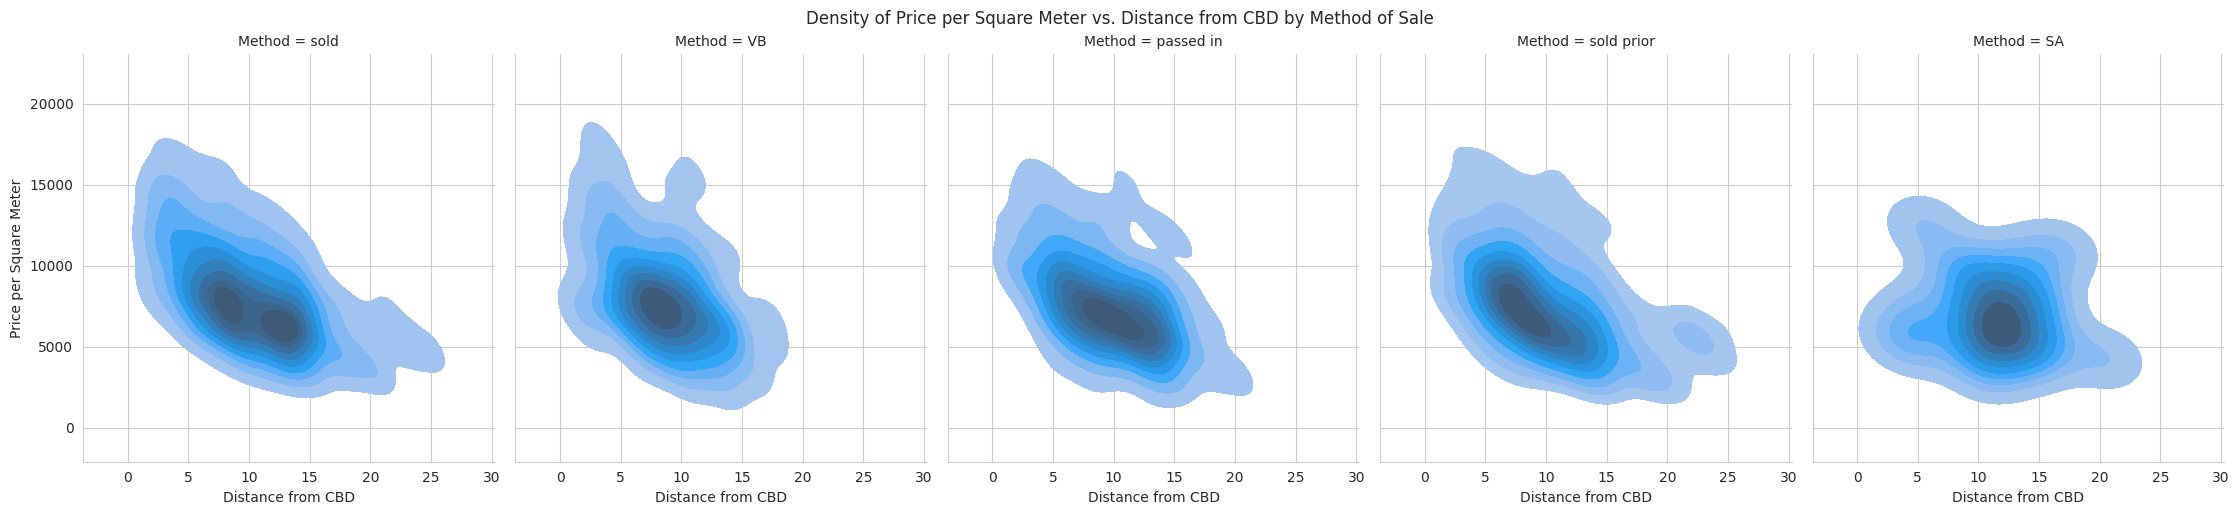

In [51]:
#facetgrid with Method by price
g = sns.FacetGrid(df, col='Method', height=5, aspect=.9)
g.map(sns.kdeplot, 'Distance', 'price_size', fill=True)
g.fig.suptitle('Density of Price per Square Meter vs. Distance from CBD by Method of Sale', y=1.02)
g.set_axis_labels('Distance from CBD', 'Price per Square Meter')

plt.show()

In [52]:
# postal codes in df with the postal codes in geo_data
geo_postcodes = geo_data['postcode'].unique()
df_filtered_postcodes = df[df['Postcode'].isin(geo_postcodes)].copy()

print(f"postal codes in the data: {df_filtered_postcodes['Postcode'].nunique()}")

postal codes in the data: 150


### Interactive Maps

In [53]:
# average price_size per postal code for filtered data
sales_per_postal_filtered = df_filtered_postcodes.groupby('Postcode')['price_size'].mean().reset_index()
sales_per_postal_filtered.rename(columns={'Postcode': 'postcode'}, inplace=True)

# unwanted outlier  postcodes from geo_data
geo_data_cleaned = geo_data[~geo_data['postcode'].isin([3081, 3490, '3081', '3037'])]
geo_data_merged_filtered = geo_data_cleaned.merge(sales_per_postal_filtered, on='postcode', how='inner')

# price_size values
geo_data_merged_filtered['price_size_rounded'] = geo_data_merged_filtered['price_size'].round(0)

# centeroids filted for post codes
center_lat = geo_data_merged_filtered.geometry.centroid.y.mean()
center_lon = geo_data_merged_filtered.geometry.centroid.x.mean()

# interactive map folium
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

folium.Choropleth(
    geo_data=geo_data_merged_filtered,
    name='Average Price per Square Meter',
    data=geo_data_merged_filtered,
    columns=['postcode', 'price_size_rounded'],
    key_on='feature.properties.postcode',
    fill_color='RdYlBu_r',
    fill_opacity=0.6,
    line_opacity=0.1,
    legend_name='Average Price per Square Meter (Rounded)',
    highlight=True
).add_to(m)

# tooltips for price_size
folium.features.GeoJson(
    geo_data_merged_filtered,
    tooltip=folium.features.GeoJsonTooltip(fields=['postcode', 'price_size_rounded'],
                                           aliases=['Postal Code:', 'Avg Price/m²:'])
).add_to(m)

folium.LayerControl().add_to(m)

display(m)

In [54]:
# average price_size, building area, and landsize per postal code
sales_and_size_per_postal_filtered = df_filtered_postcodes.groupby('Postcode')[['price_size', 'BuildingArea', 'Landsize']].mean().reset_index()
sales_and_size_per_postal_filtered.rename(columns={'Postcode': 'postcode'}, inplace=True)

#sales and size data with geodata
geo_data_merged_filtered = geo_data.merge(sales_and_size_per_postal_filtered, on='postcode', how='inner')

# round
geo_data_merged_filtered['price_size_rounded'] = geo_data_merged_filtered['price_size'].round(0)
geo_data_merged_filtered['BuildingArea_rounded'] = geo_data_merged_filtered['BuildingArea'].round(0)
geo_data_merged_filtered['Landsize_rounded'] = geo_data_merged_filtered['Landsize'].round(0)



# centeroids filted for post codes
center_lat = geo_data_merged_filtered.geometry.centroid.y.mean()
center_lon = geo_data_merged_filtered.geometry.centroid.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

folium.Choropleth(
    geo_data=geo_data_merged_filtered,
    name='Average Building Size',
    data=geo_data_merged_filtered,
    columns=['postcode', 'BuildingArea_rounded'],  # Use Landsize_rounded for coloring
    key_on='feature.properties.postcode',
    fill_color='RdYlBu', # You can choose a different colormap if desired
    fill_opacity=0.6,
    line_opacity=0.1,
    legend_name='Average buildingsize', # Update legend name
    highlight=True
).add_to(m)

# tooltips
folium.features.GeoJson(
    geo_data_merged_filtered,
    tooltip=folium.features.GeoJsonTooltip(fields=['postcode', 'price_size_rounded', 'BuildingArea_rounded', 'Landsize_rounded'],
                                           aliases=['Postal Code:', 'Avg Price/m²:', 'Avg Bldg Area (m²):', 'Avg Landsize (m²):'])
).add_to(m)

folium.LayerControl().add_to(m)

display(m)

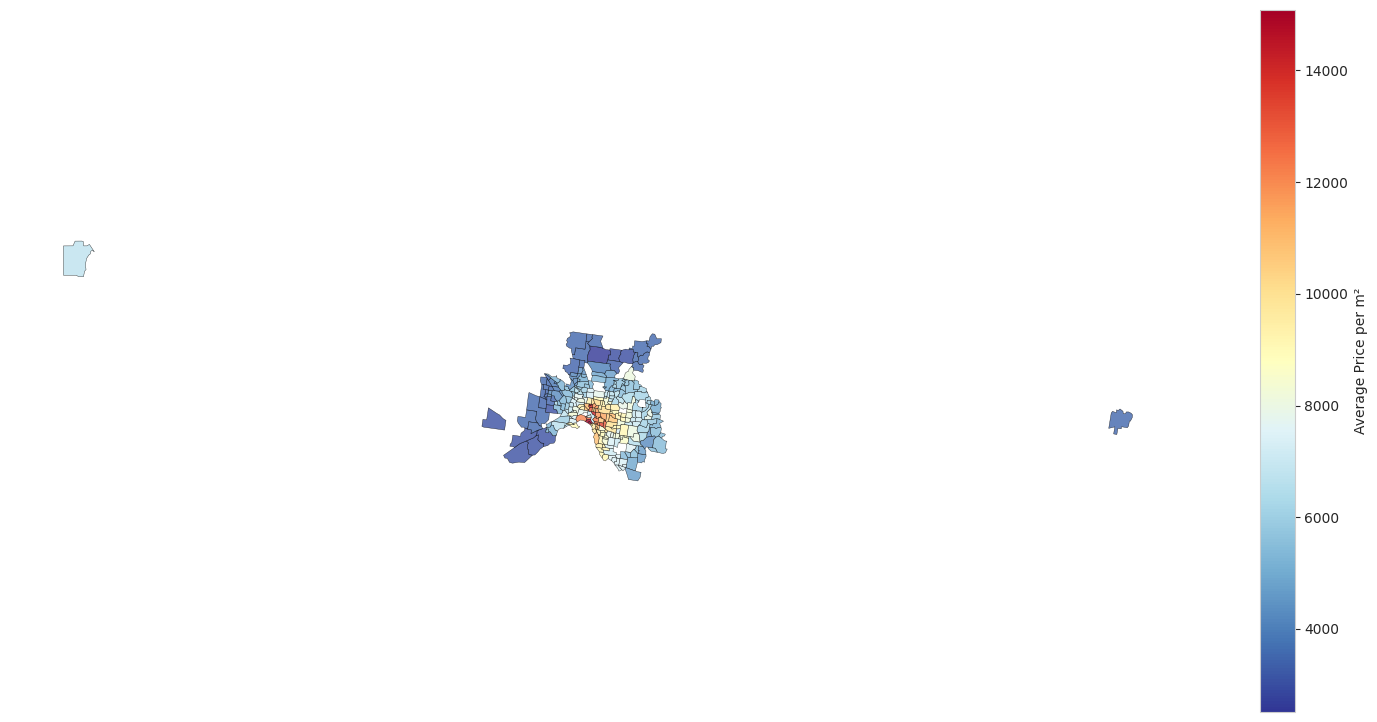

In [55]:
sns.set_style("whitegrid")

# Filter out unwanted postcodes from geo_data
geo_data_cleaned = geo_data[~geo_data['postcode'].isin([3081, 3490, '3081', '3037'])].copy()
# round
geo_data_merged_filtered['price_size_rounded'] = geo_data_merged_filtered['price_size'].round(0)

fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# color from regression plot to match
cmap = plt.cm.RdYlBu_r

# choropleth
geo_data_merged_filtered.plot(
    column='price_size_rounded',
    ax=ax,
    legend=True,
    cmap=cmap,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={
        'label': 'Average Price per m²',
        'orientation': 'vertical',
        'shrink': 0.6
    }
)

#ax.set_title('Average Price per Square Meter by Postal Code', fontsize=16, fontweight='bold')
#ax.set_xlabel('Longitude', fontsize=12)
#ax.set_ylabel('Latitude', fontsize=12)
#ax.set_aspect('equal')
ax.set_axis_off()
plt.tight_layout()
plt.show()
